In [53]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch

In [54]:
# Открываем файл и указываем путь к дереву
file_event = uproot.open("./output/mc_reco_event.root")
tree_event = file_event["eRecoTree;1"]

file_pulse = uproot.open("./output/mc_reco_pulse.root")
tree_pulse = file_pulse["pRecoTree;2"]

# Читаем все ветки в Pandas DataFrame
df_event = tree_event.arrays(library="pd")
df_pulse = tree_pulse.arrays(library="pd")

In [55]:
df_event.head()

,eventId,nMuons,trueTime,eventWeight,theta,phi,refTime
0,2,18,1875.260864,1.0,178.640610,45.199497,1613.487915
1,3,9,1661.550781,1.0,140.550919,227.875488,1541.505615
2,4,28,1696.281128,1.0,156.506882,57.969051,1727.733154
3,5,2,1389.490723,1.0,81.043404,309.033966,1465.595093
4,6,10,1968.123413,1.0,117.983086,49.720161,1897.095459


In [56]:
df_pulse.head()

,eventId,chanID,pulseLY,pulseTime,dTime,distToPoint_BH
0,3,9,10.334139,1310.158936,-231.346680,7.504611
1,3,181,6.322230,1820.356812,278.851196,6.398116
2,3,183,5.286264,1772.637695,231.132080,16.769716
3,4,285,5.302313,1371.158813,-356.574341,30.144203
4,5,34,7.179919,1708.128662,242.533569,37.248791


In [57]:
df_merged = df_pulse.merge(df_event, how = "left", on = "eventId")
df_merged.head()

,eventId,chanID,pulseLY,pulseTime,dTime,distToPoint_BH,nMuons,trueTime,eventWeight,theta,phi,refTime
0,3,9,10.334139,1310.158936,-231.346680,7.504611,9,1661.550781,1.0,140.550919,227.875488,1541.505615
1,3,181,6.322230,1820.356812,278.851196,6.398116,9,1661.550781,1.0,140.550919,227.875488,1541.505615
2,3,183,5.286264,1772.637695,231.132080,16.769716,9,1661.550781,1.0,140.550919,227.875488,1541.505615
3,4,285,5.302313,1371.158813,-356.574341,30.144203,28,1696.281128,1.0,156.506882,57.969051,1727.733154
4,5,34,7.179919,1708.128662,242.533569,37.248791,2,1389.490723,1.0,81.043404,309.033966,1465.595093


In [ ]:
df_grouped = df_merge.groupby(["eventId"])

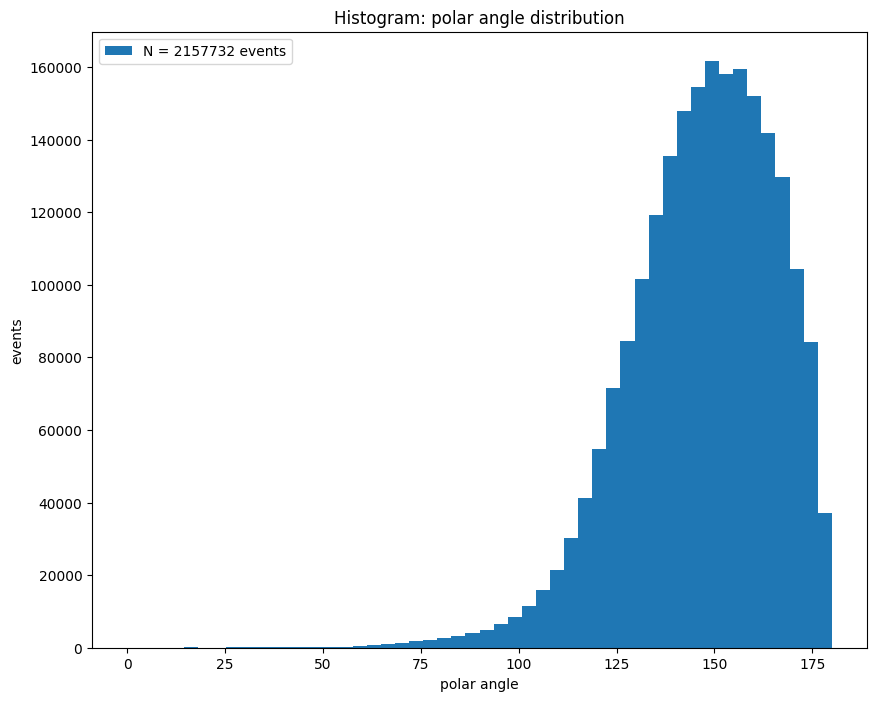

In [58]:
plt.figure(figsize=(10, 8))
n_events = len(df_merged)
plt.hist(df_merged['theta'], bins=50, label=f'N = {n_events} events')

plt.xlabel('polar angle')
plt.ylabel('events')
plt.title('Histogram: polar angle distribution')
plt.legend()
plt.show()

In [73]:
def LY_vs_dist_ploter(df):
    """Создает и возвращает фигуру с 2D гистограммой"""
    fig, ax = plt.subplots(figsize=(10, 8))
    n_events = len(df)
    h = ax.hist2d(df['distToPoint_BH'], df['pulseLY'], 
                  bins=[100, 100],
                  cmap='viridis',
                  norm='log')
    
    plt.colorbar(h[3], ax=ax, label='Counts')
    ax.set_xlabel('distToPoint_BH')
    ax.set_ylabel('pulseLY')
    
    # Округляем значения theta
    min_theta = round(df.theta.min(), 1)
    max_theta = round(df.theta.max(), 1)
    ax.set_title(f'2D Histogram: pulseLY vs distToPoint_BH, theta from {min_theta} to {max_theta}')

    legend_elements = [Patch(facecolor='none', edgecolor='none', 
                             label=f'N = {n_events} events')]
    ax.legend(handles=legend_elements, loc='upper right')
    
    return fig  # Возвращаем объект фигуры

/var/folders/gy/92sb6trn21j21_xjd024bdvc0000gq/T/ipykernel_14376/3720872591.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 8))


PDF сохранен как 'histograms_theta.pdf'


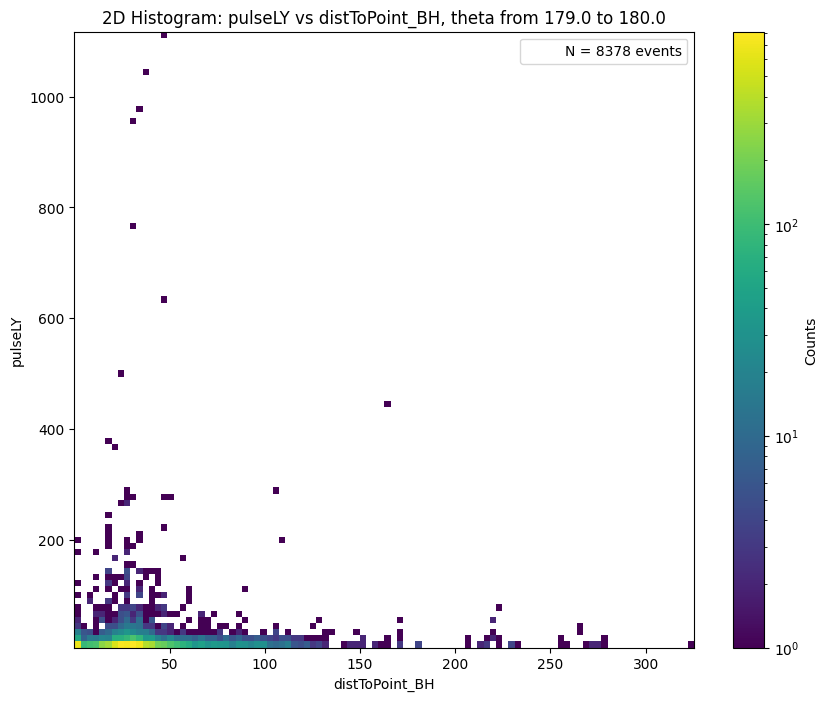

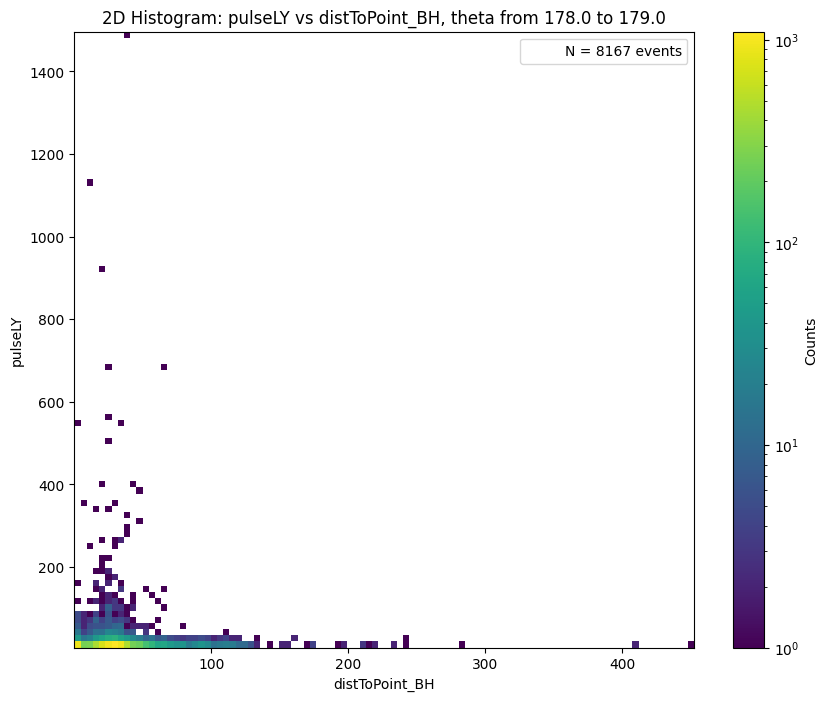

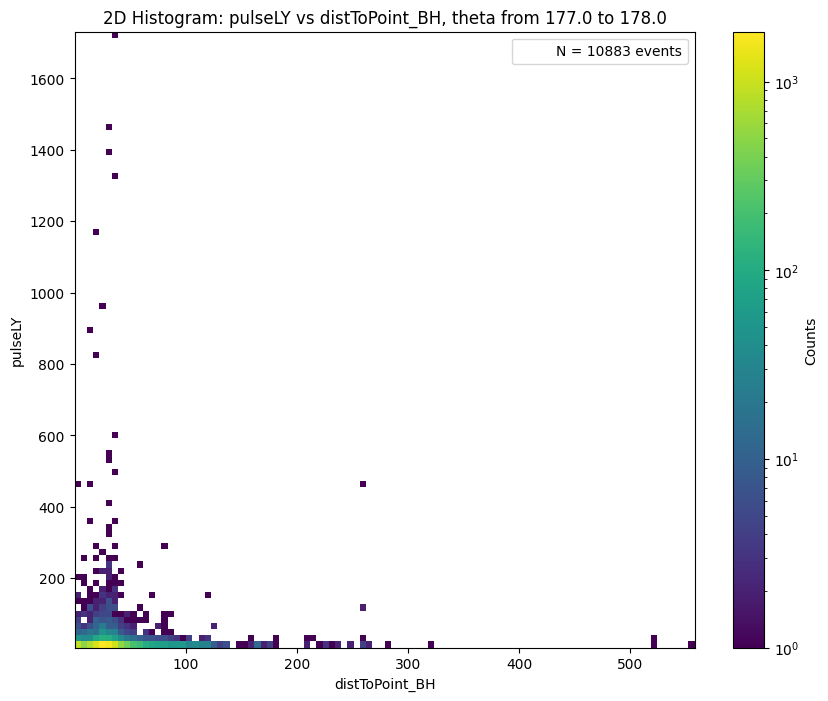

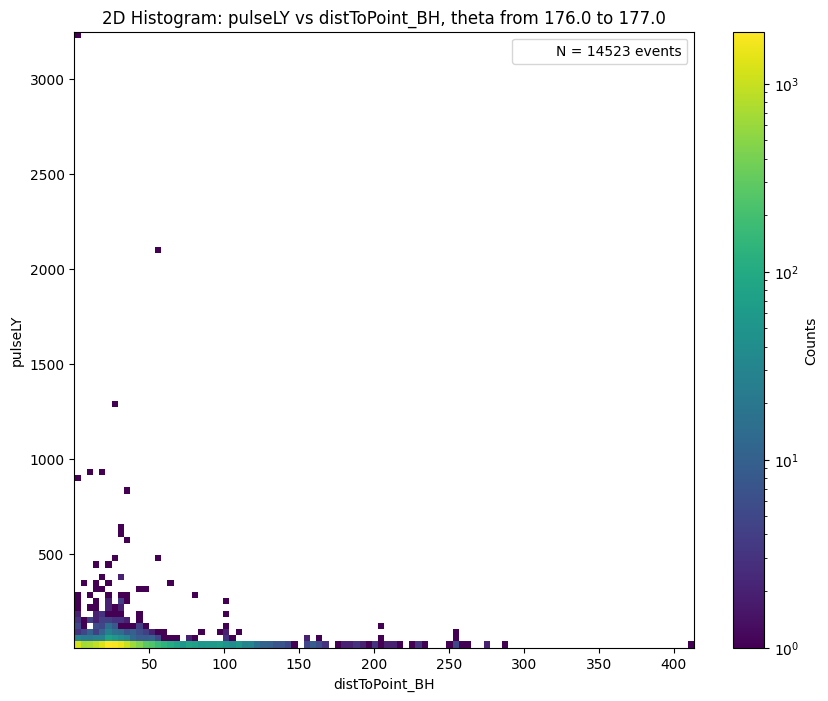

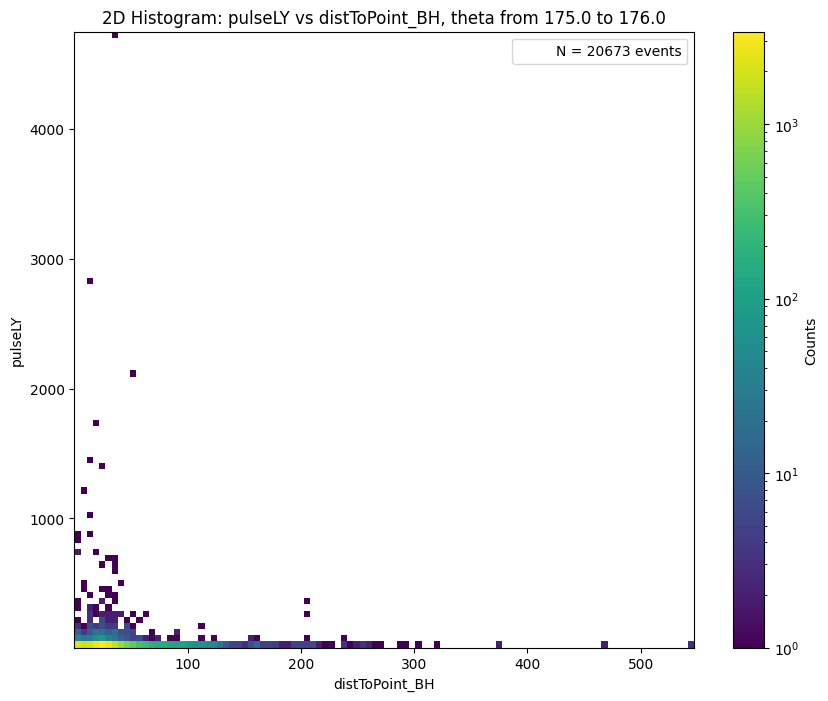

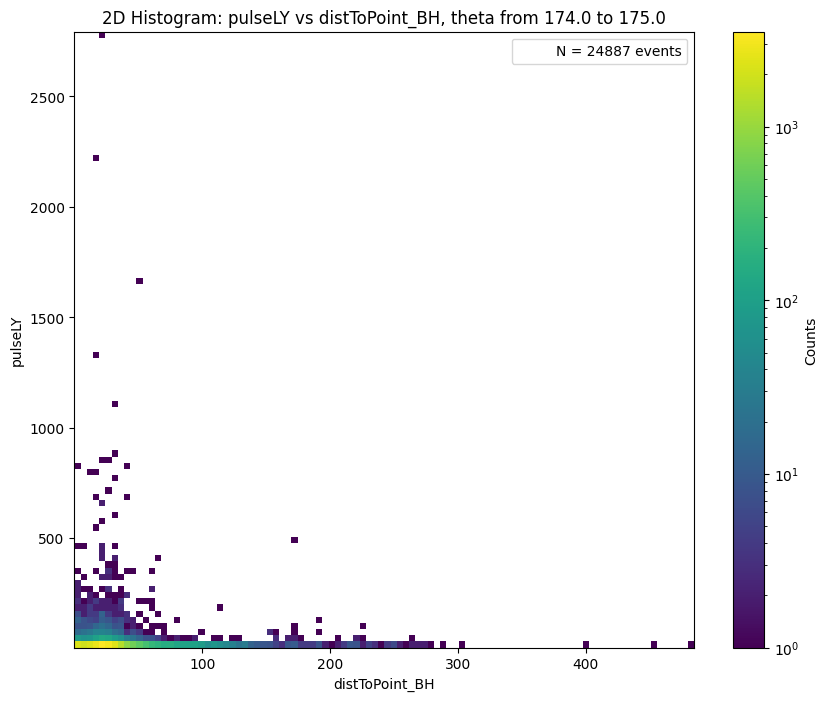

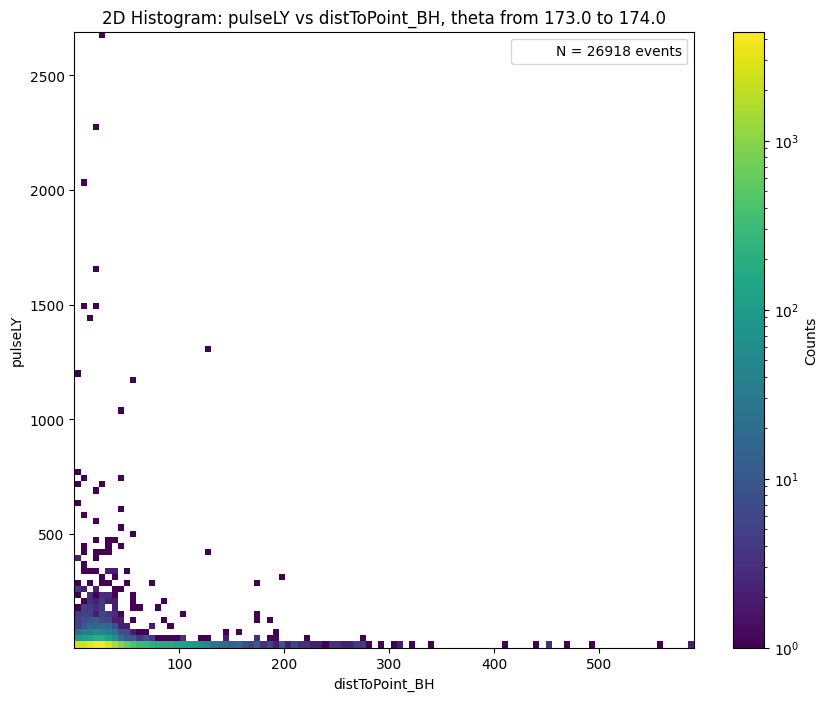

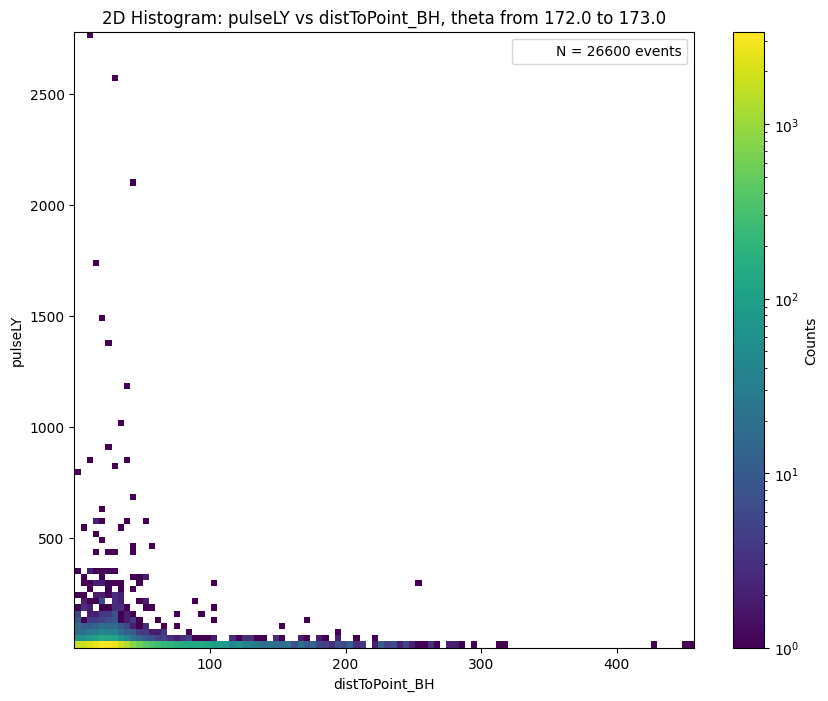

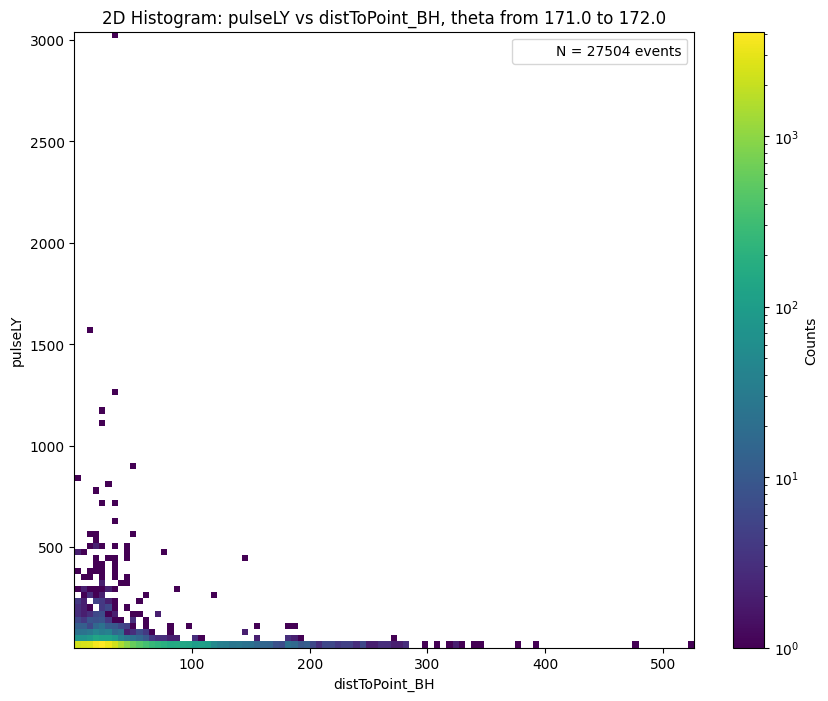

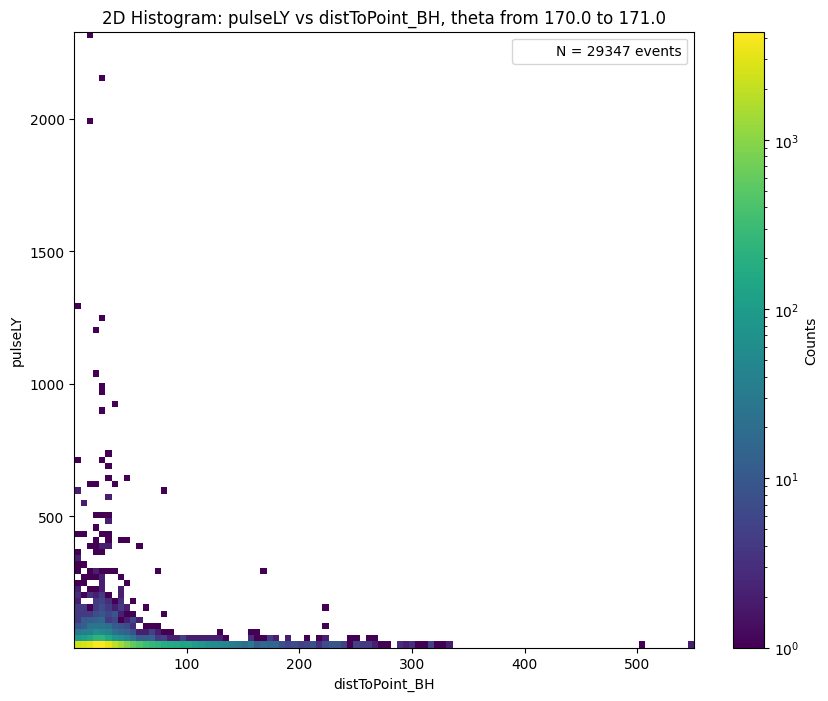

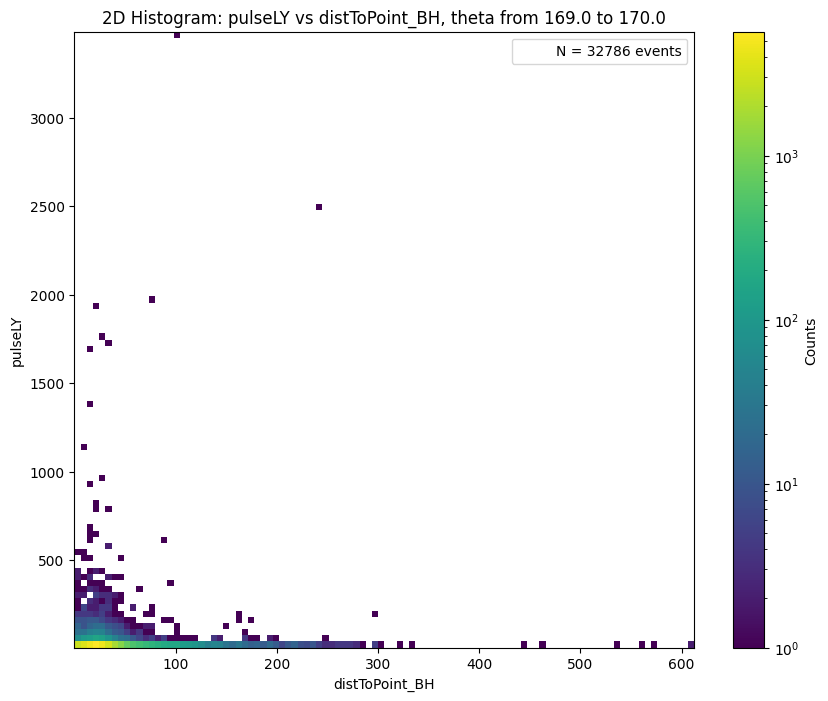

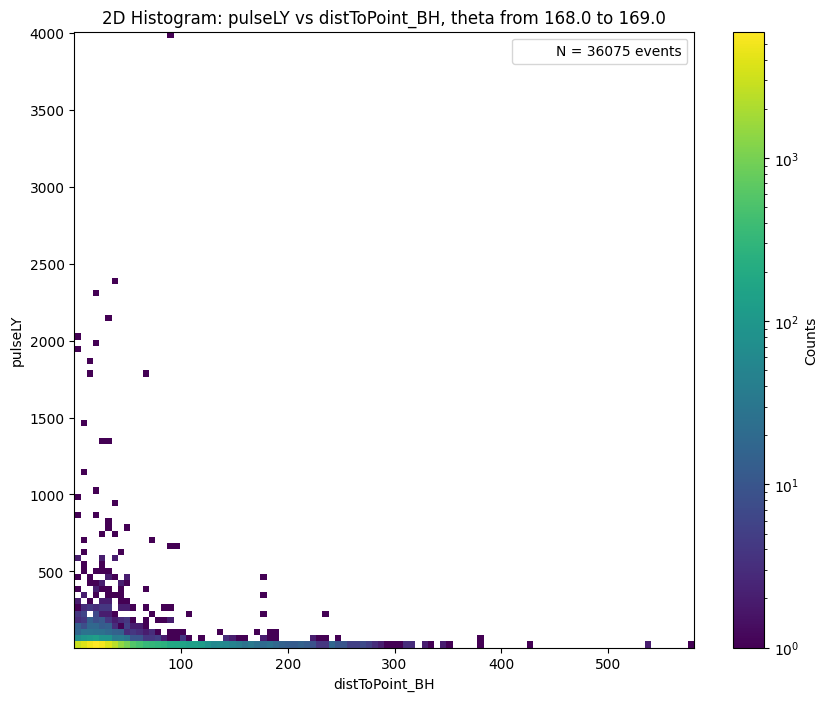

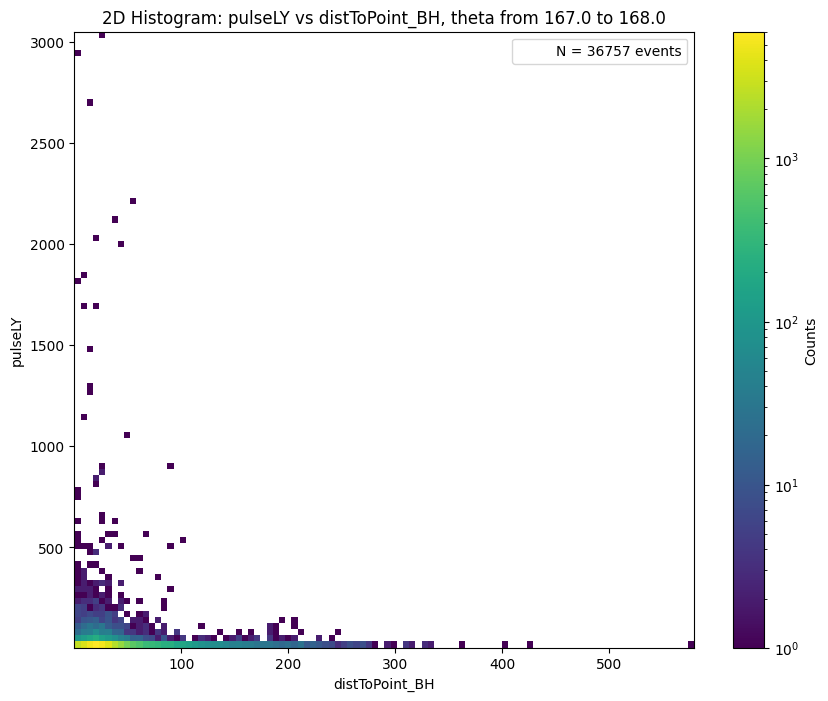

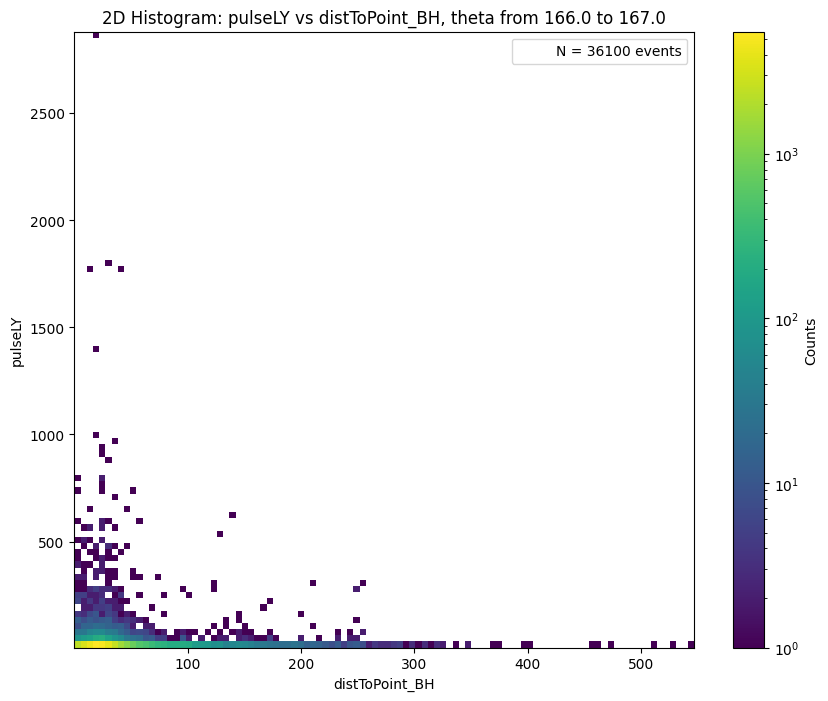

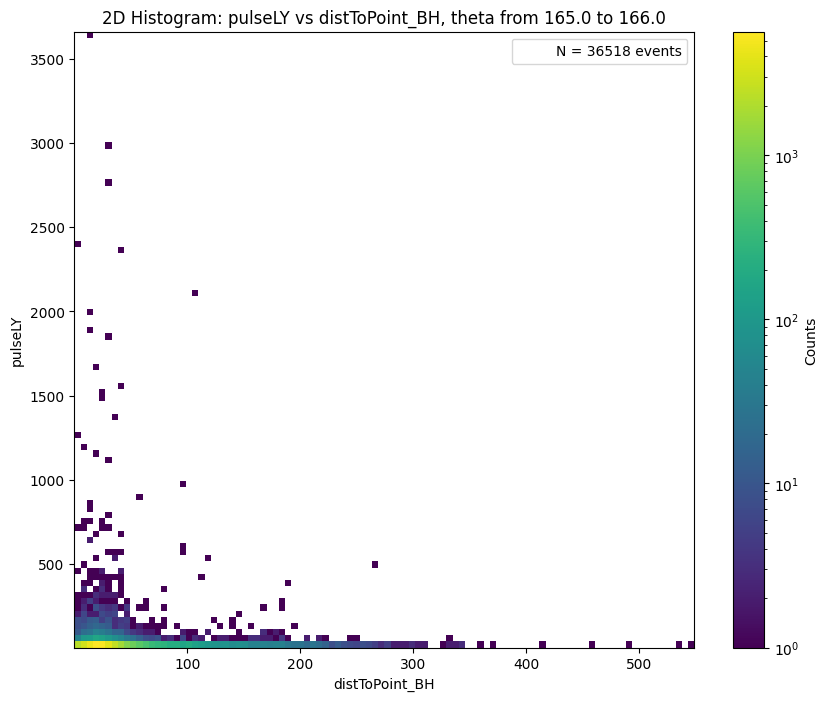

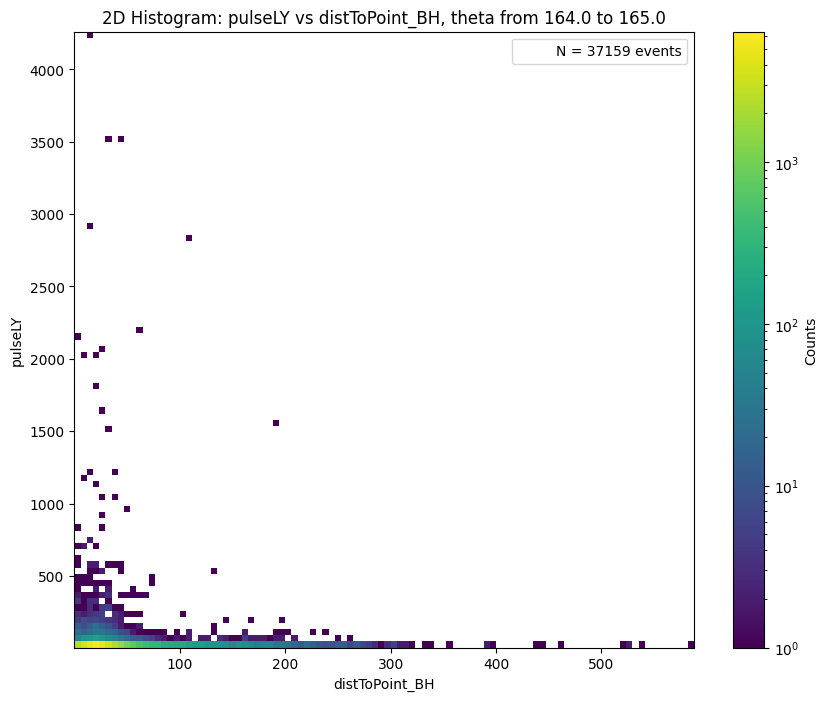

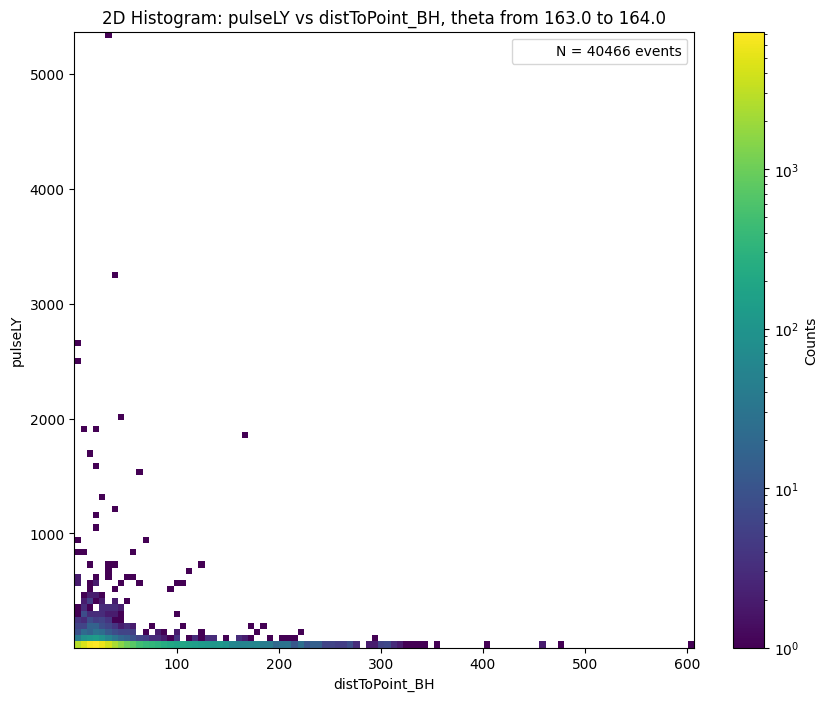

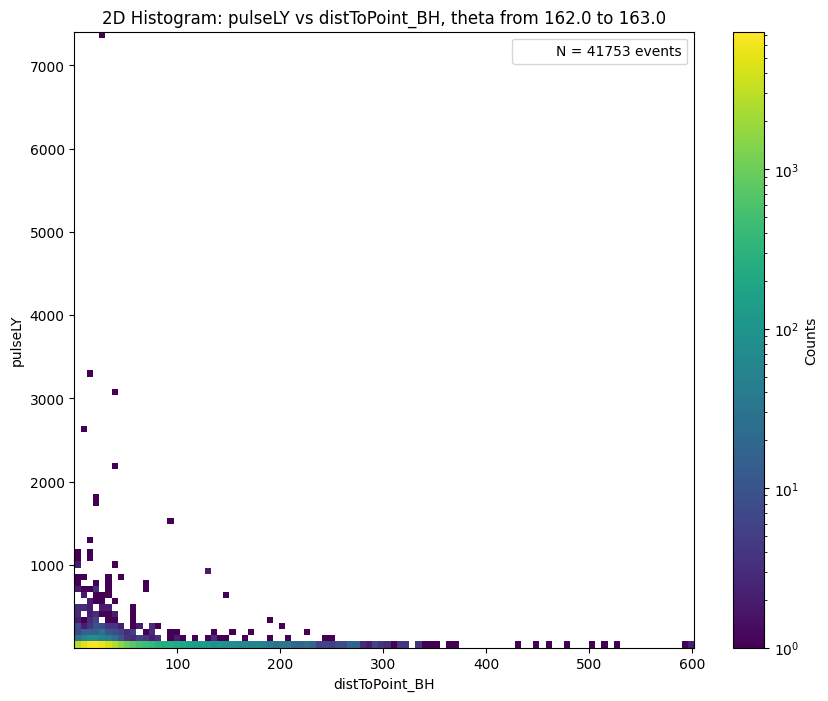

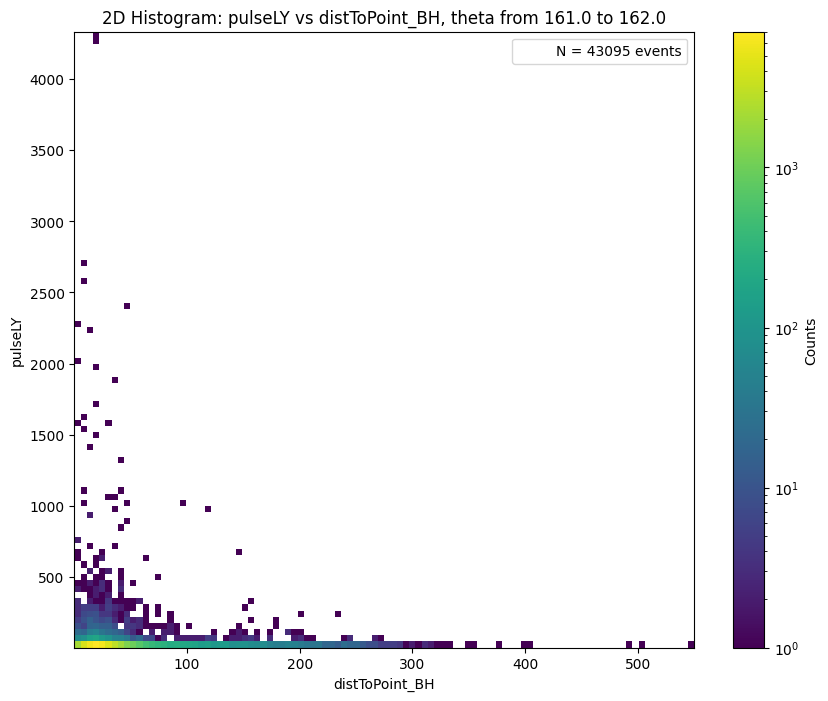

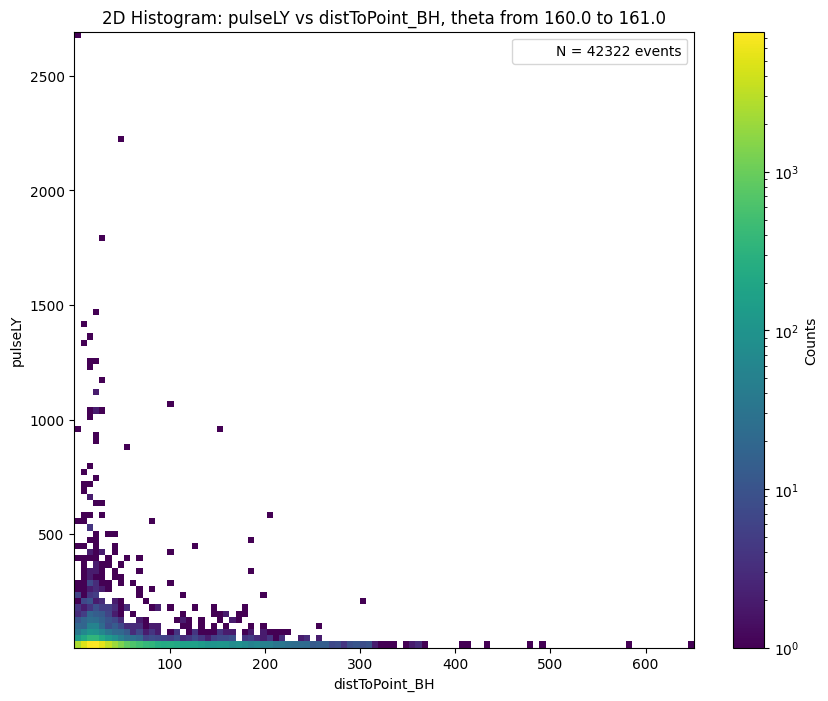

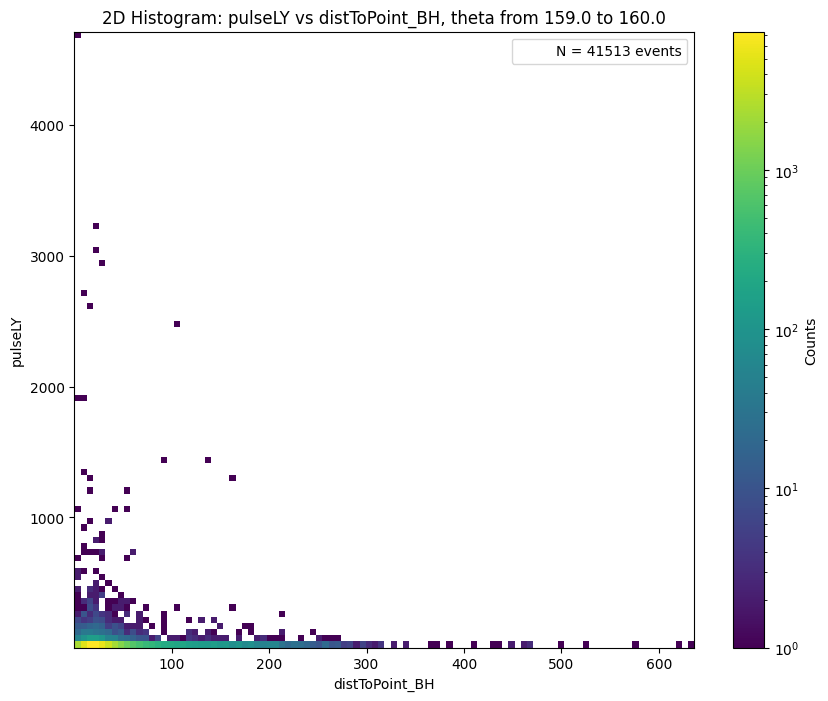

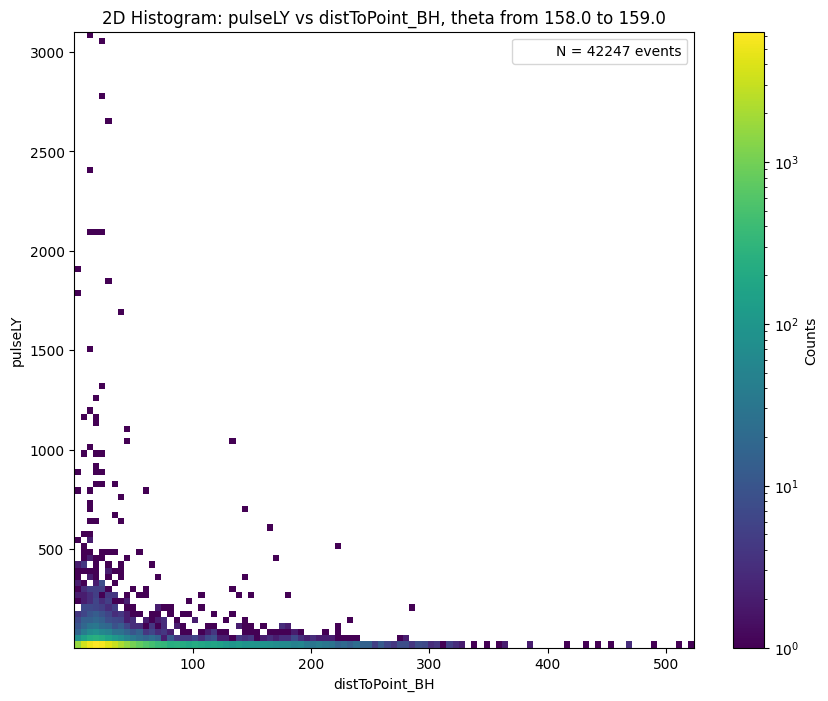

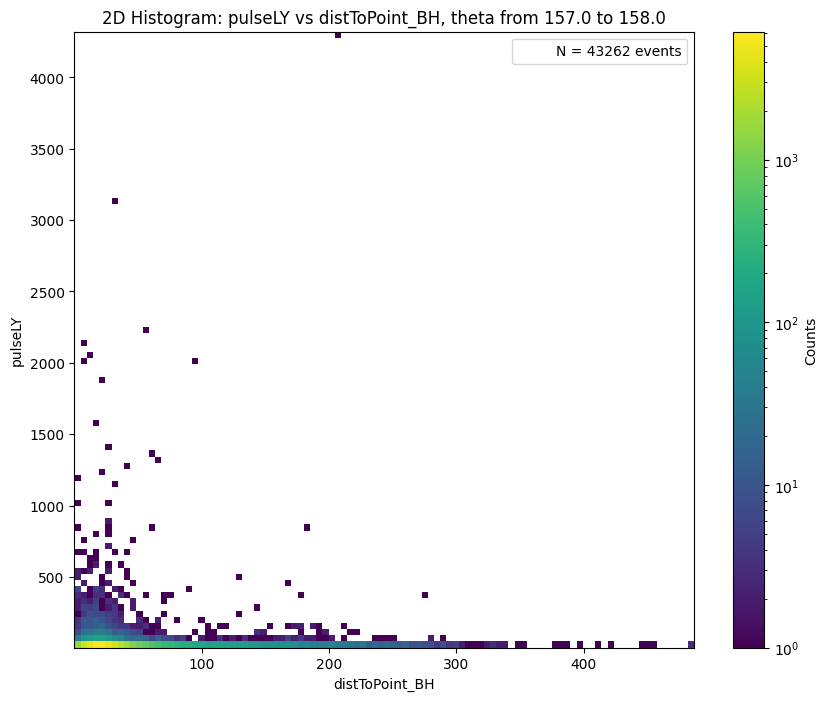

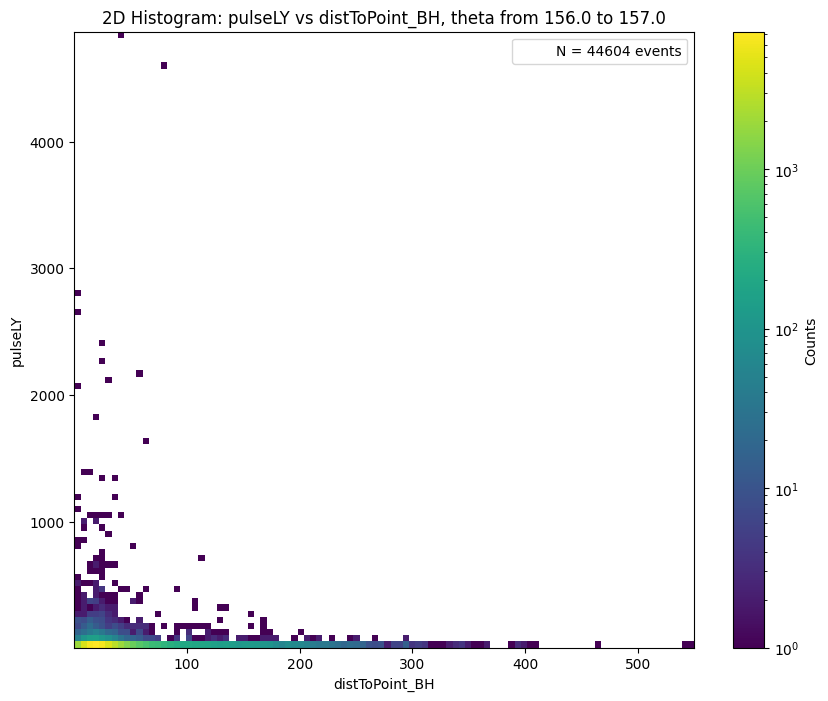

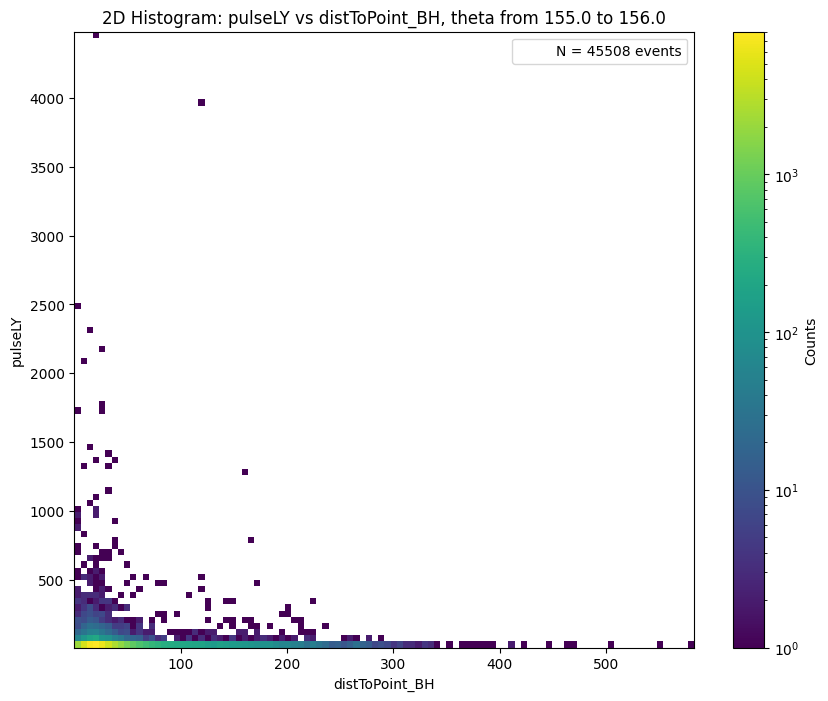

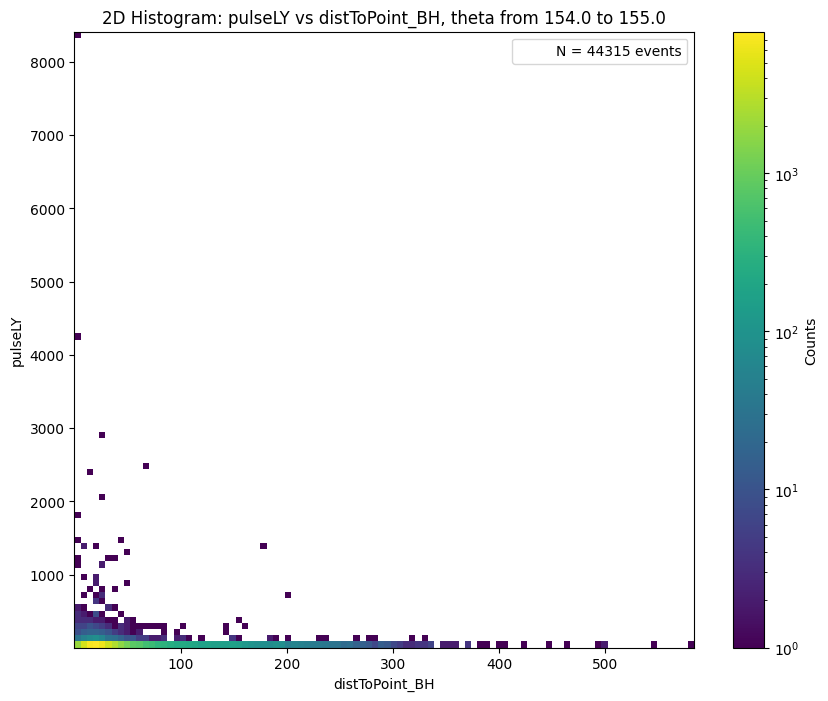

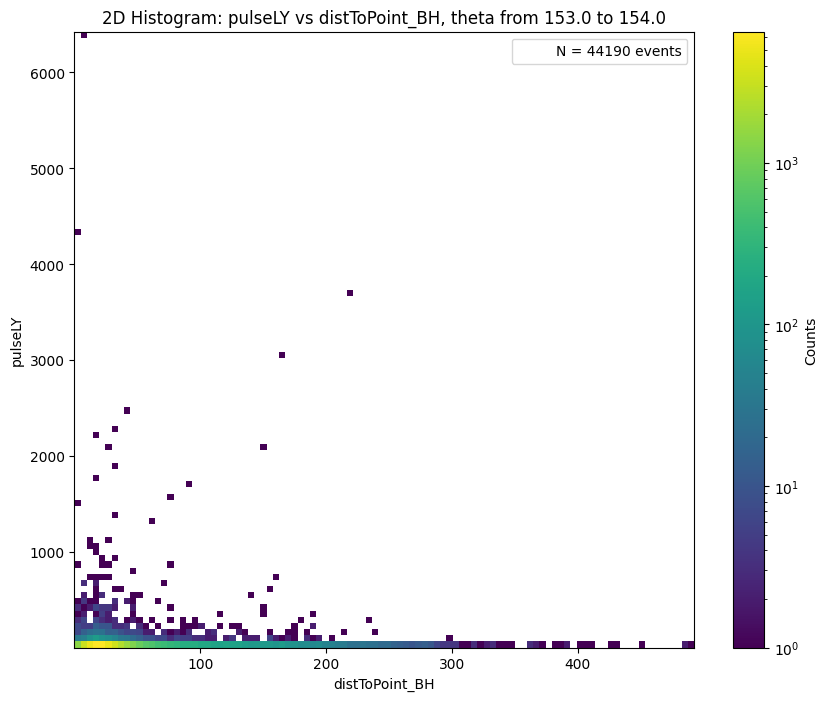

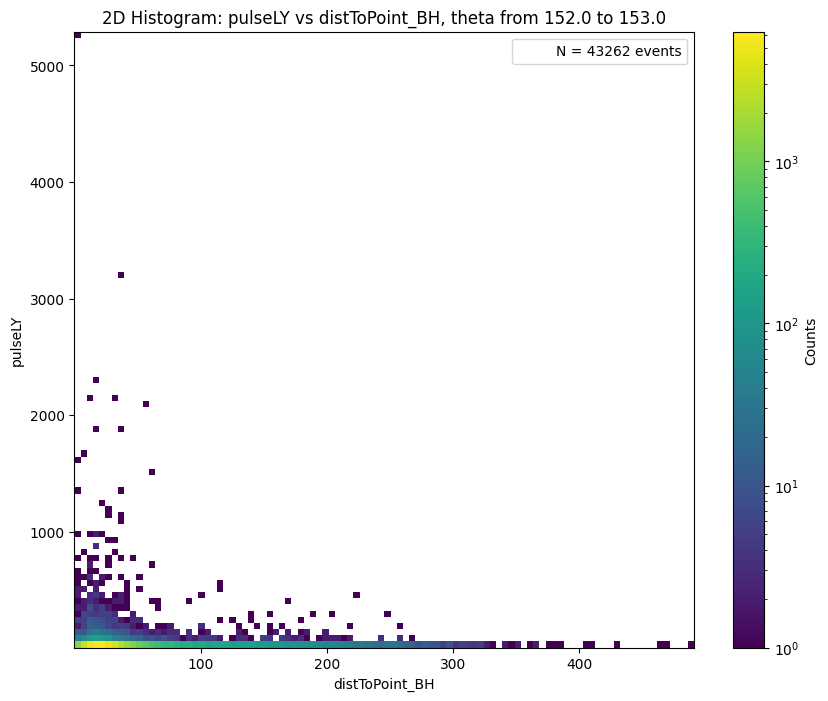

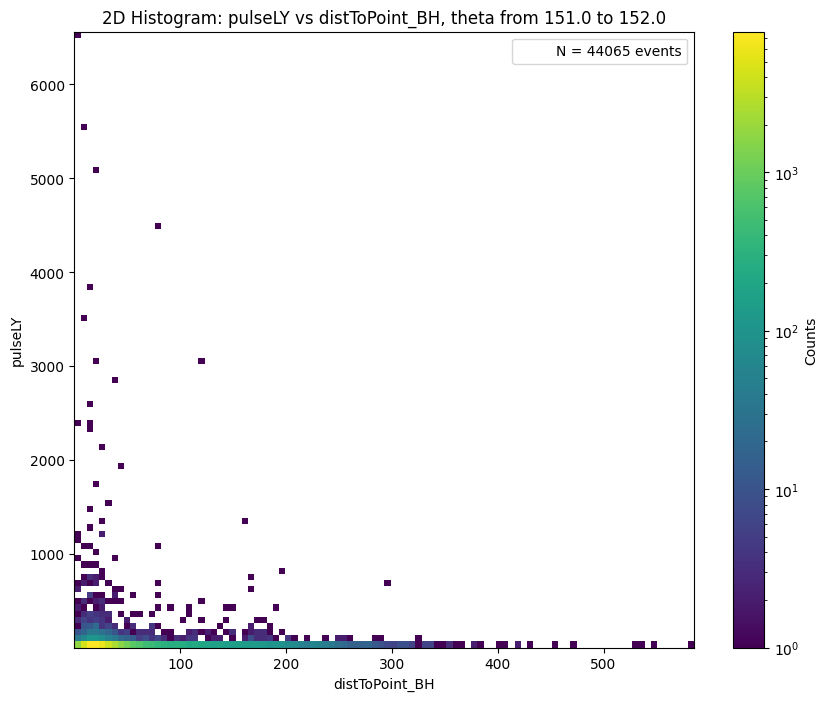

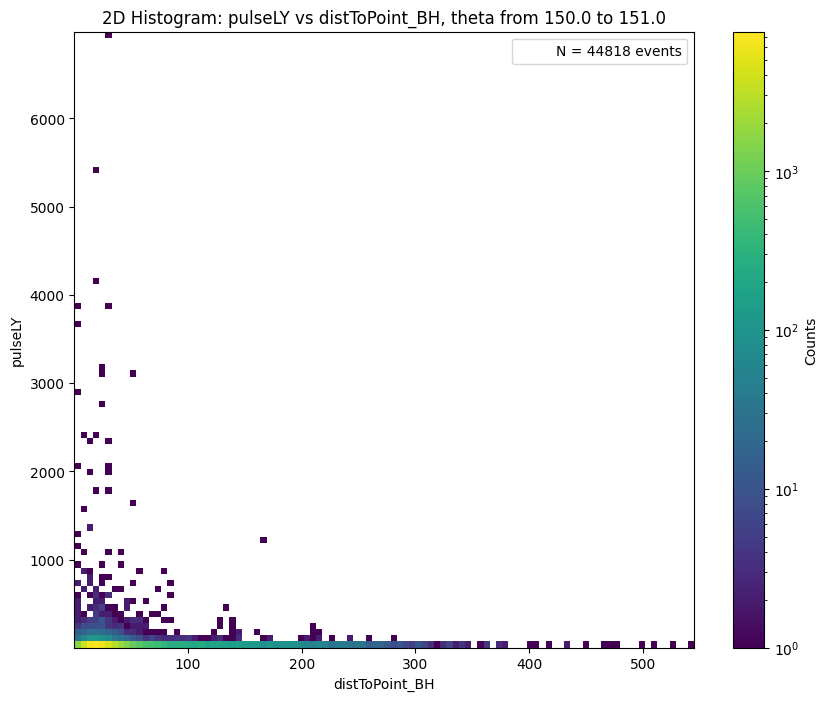

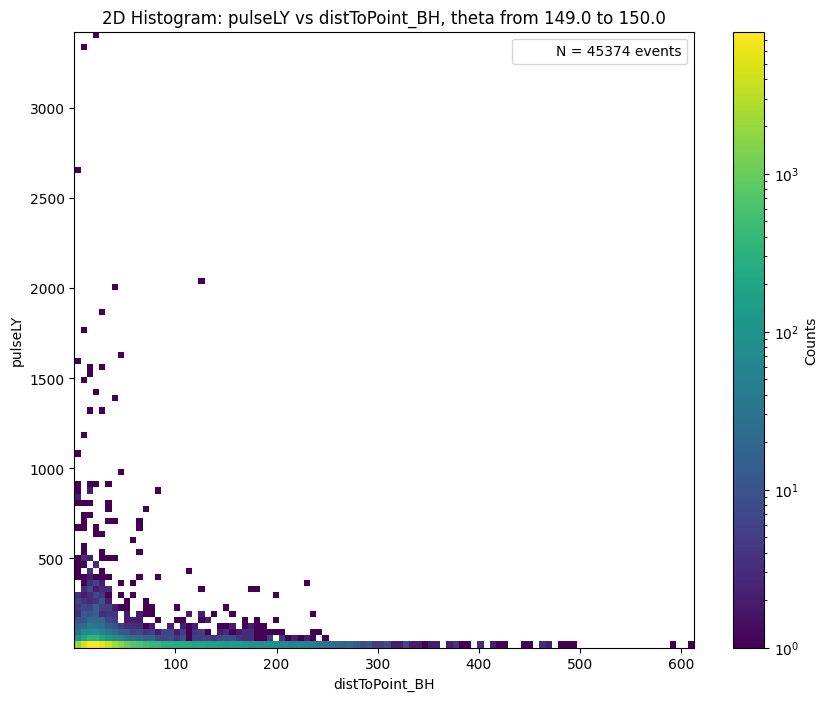

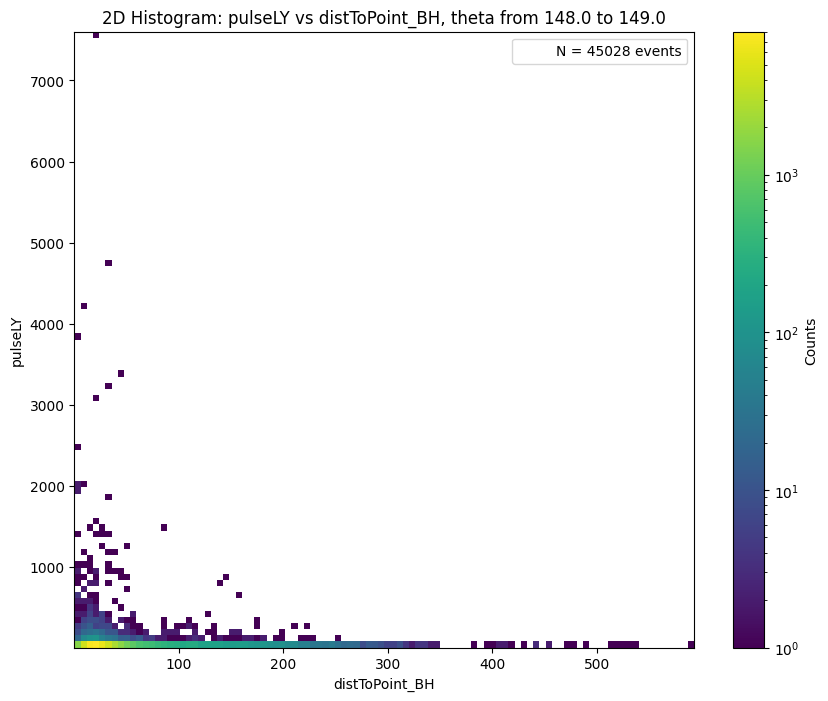

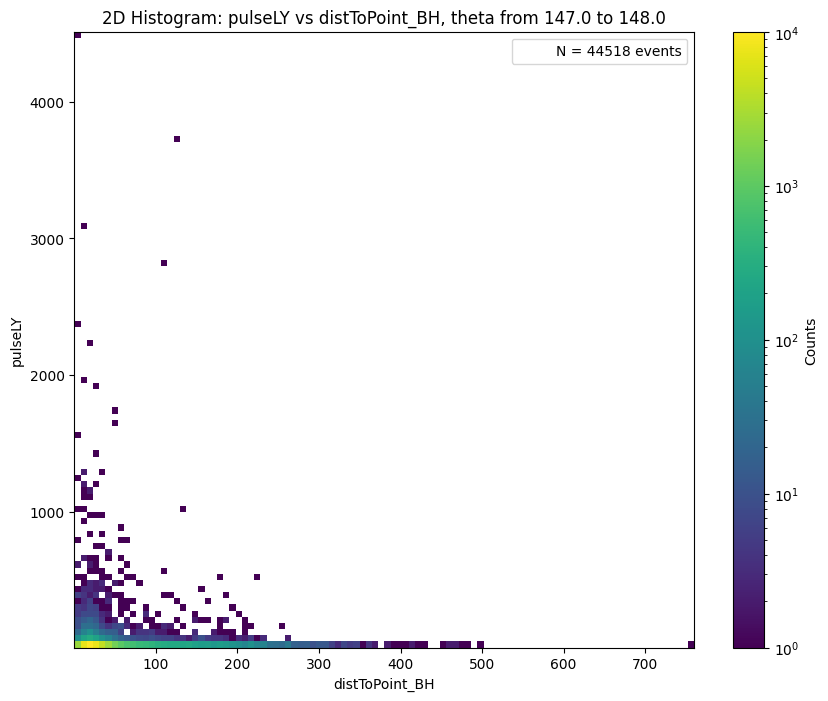

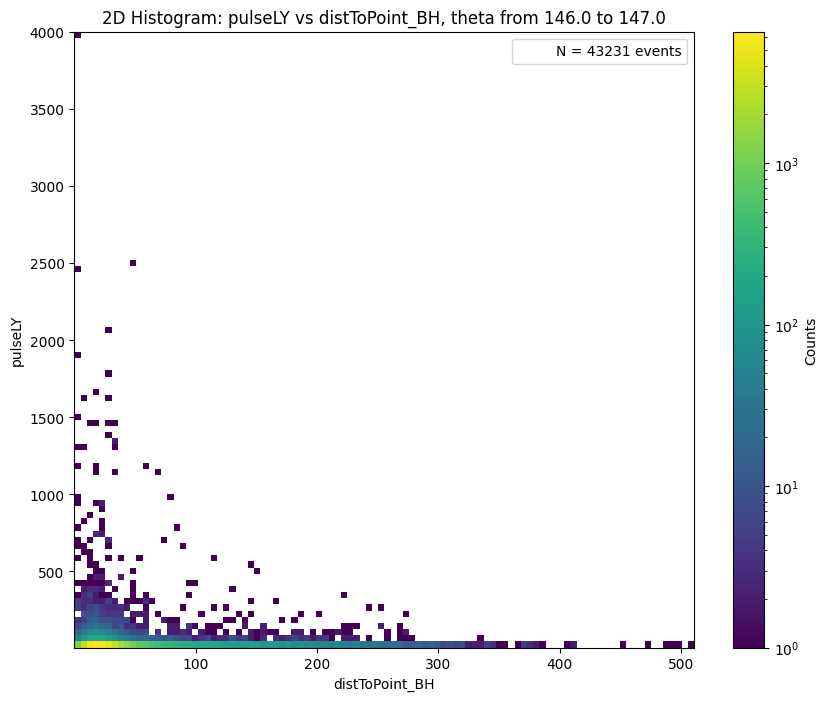

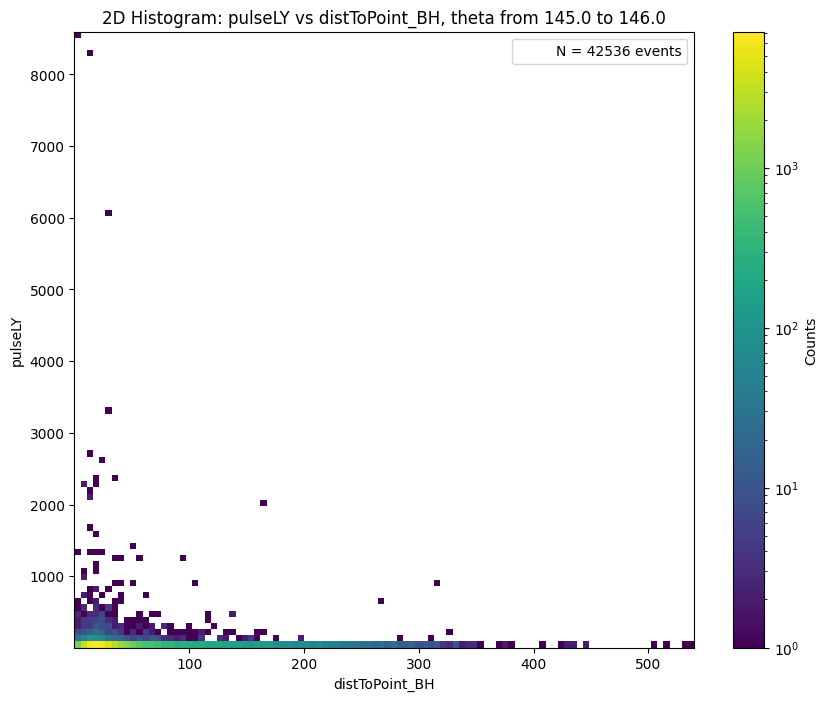

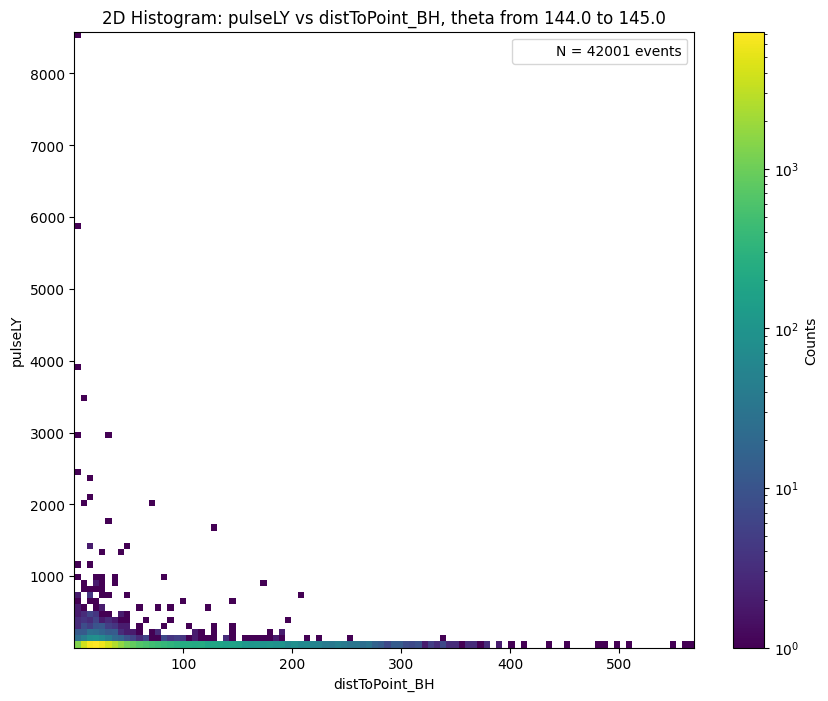

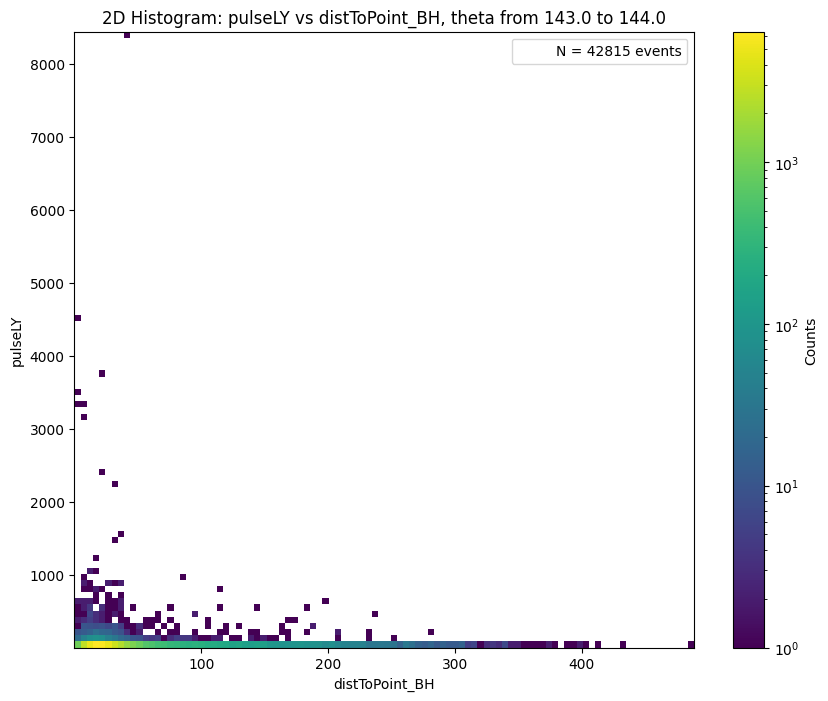

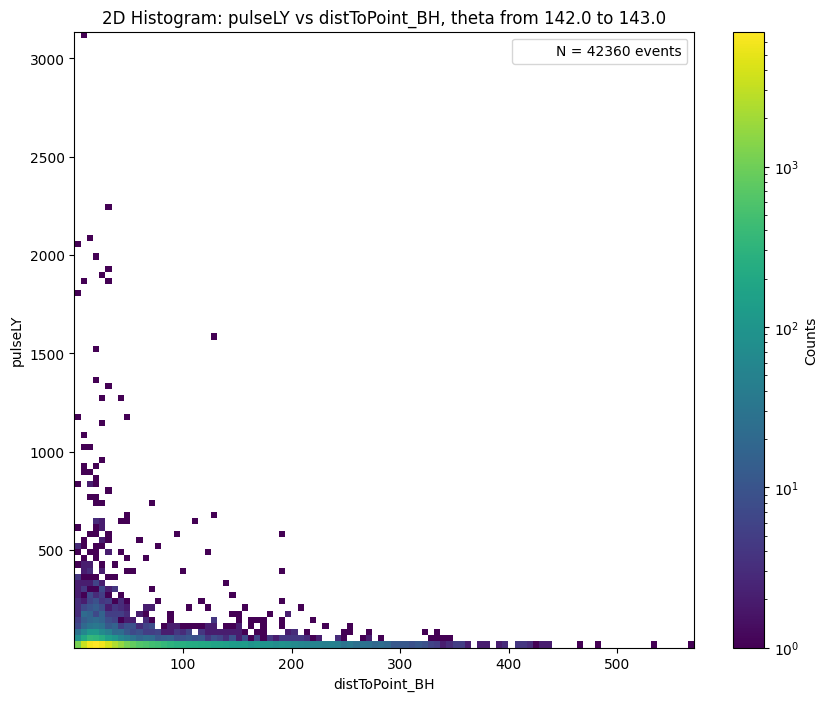

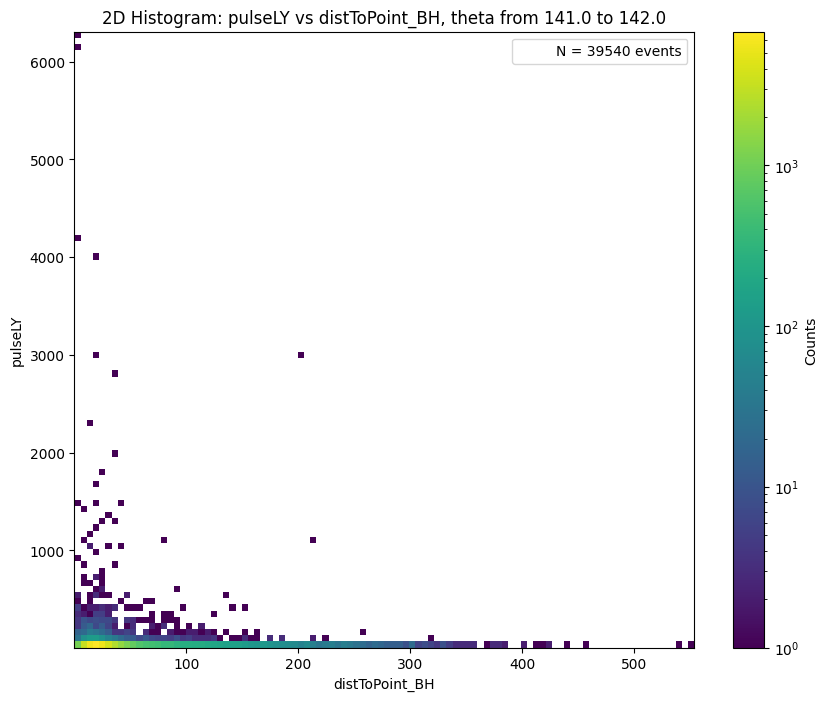

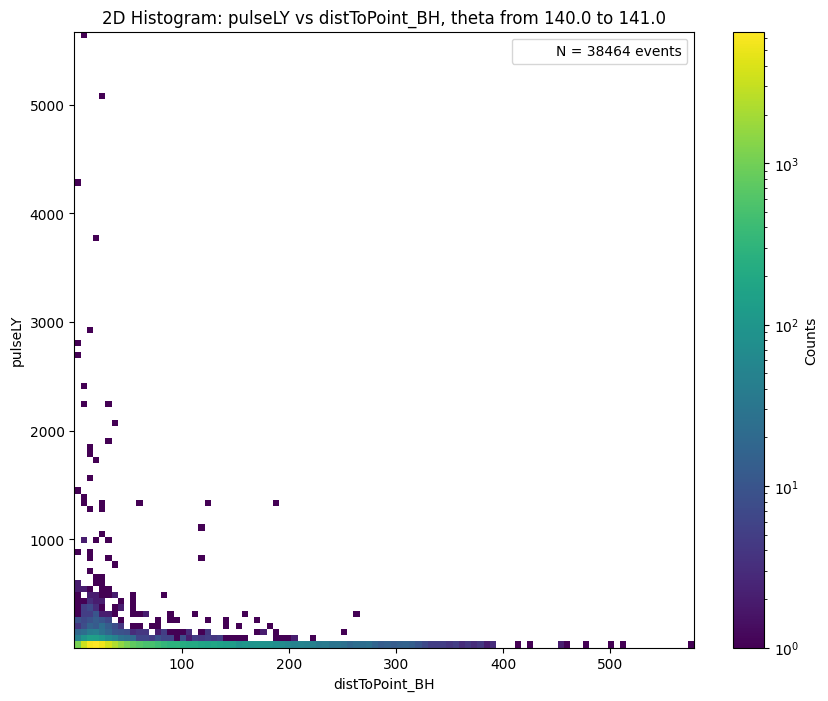

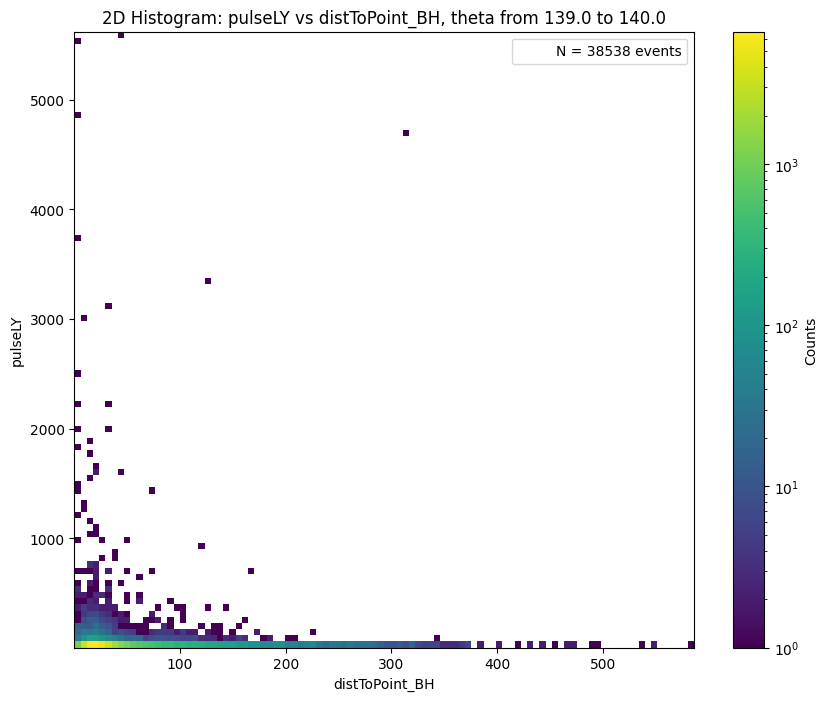

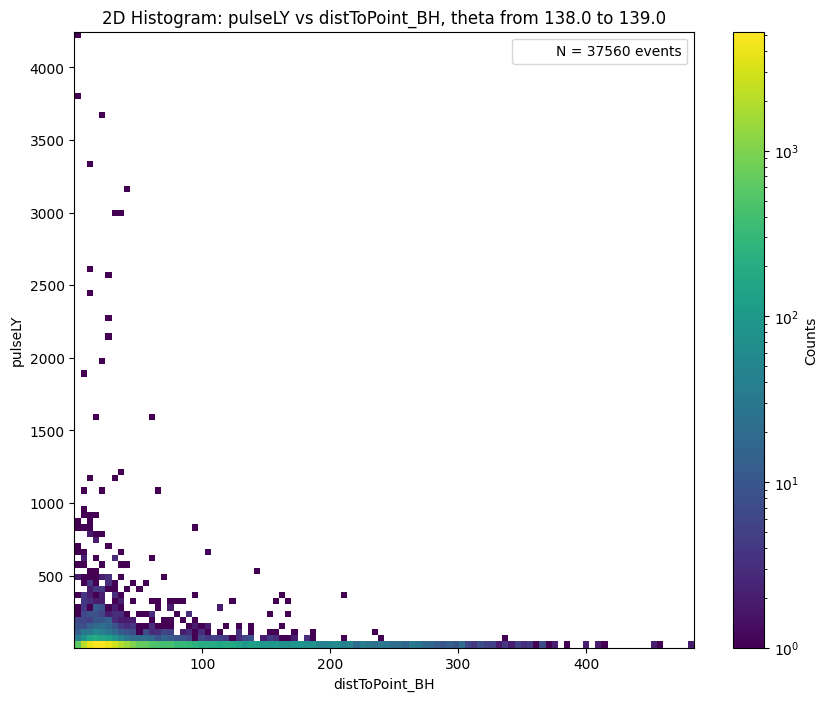

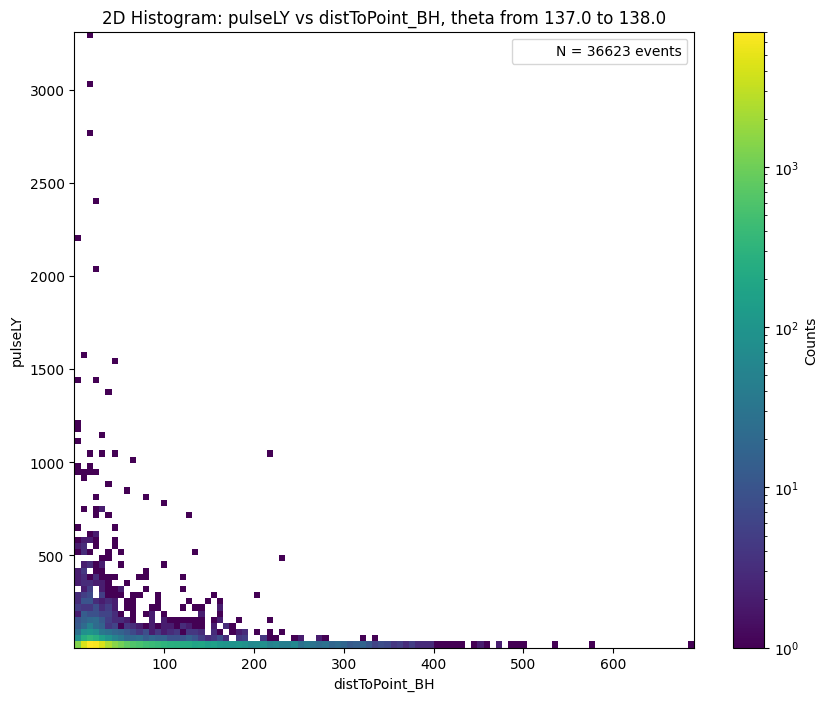

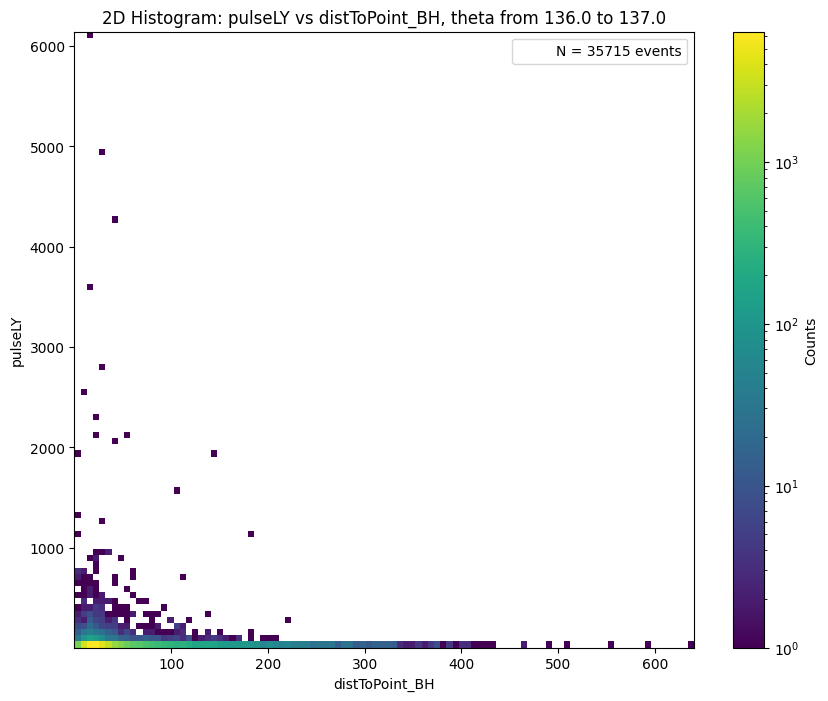

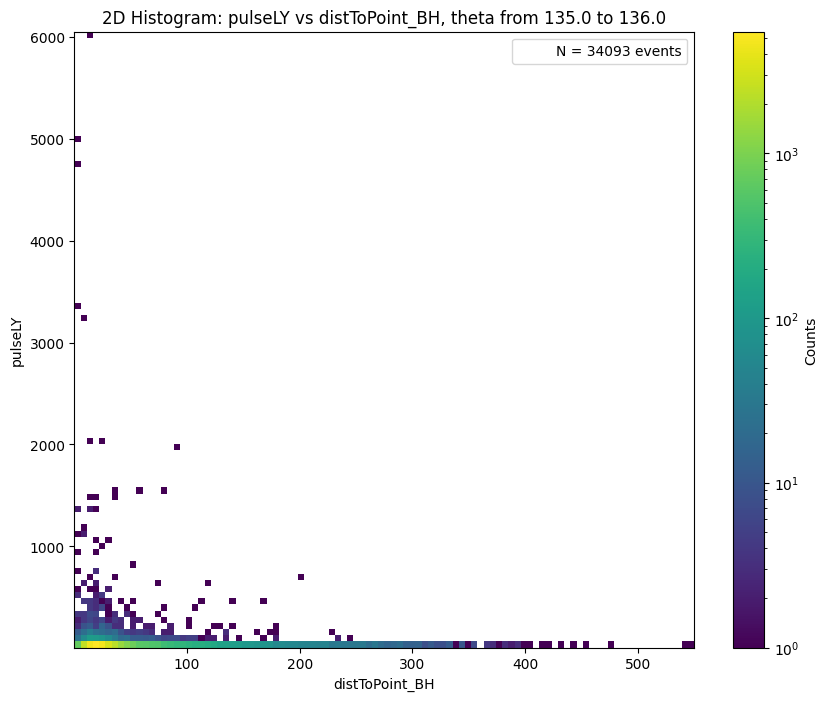

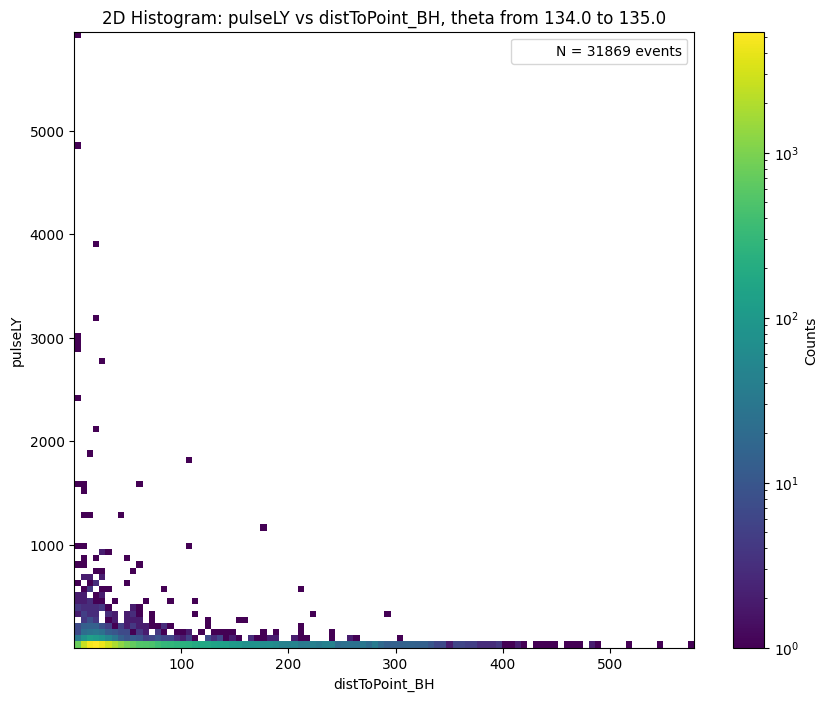

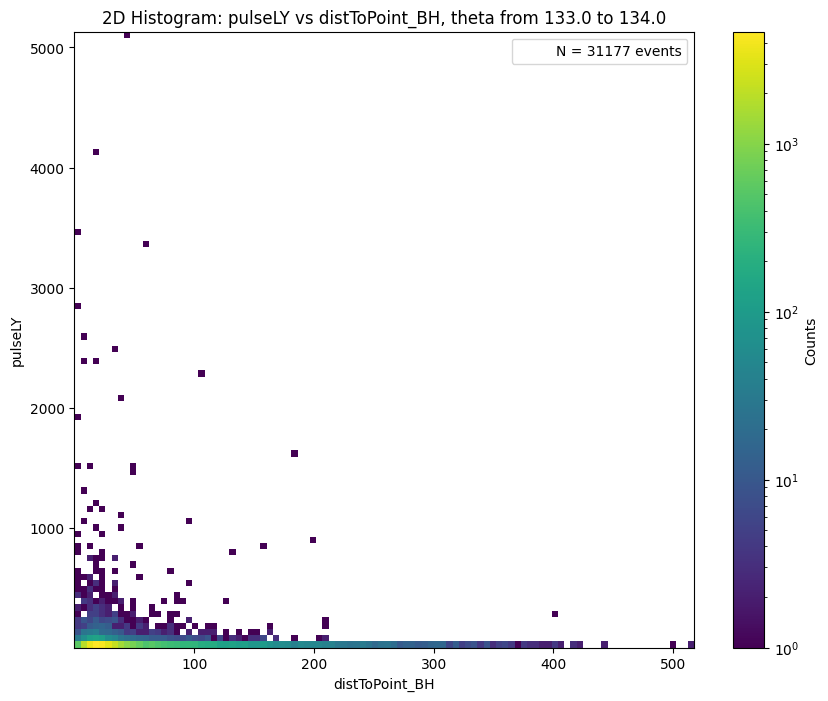

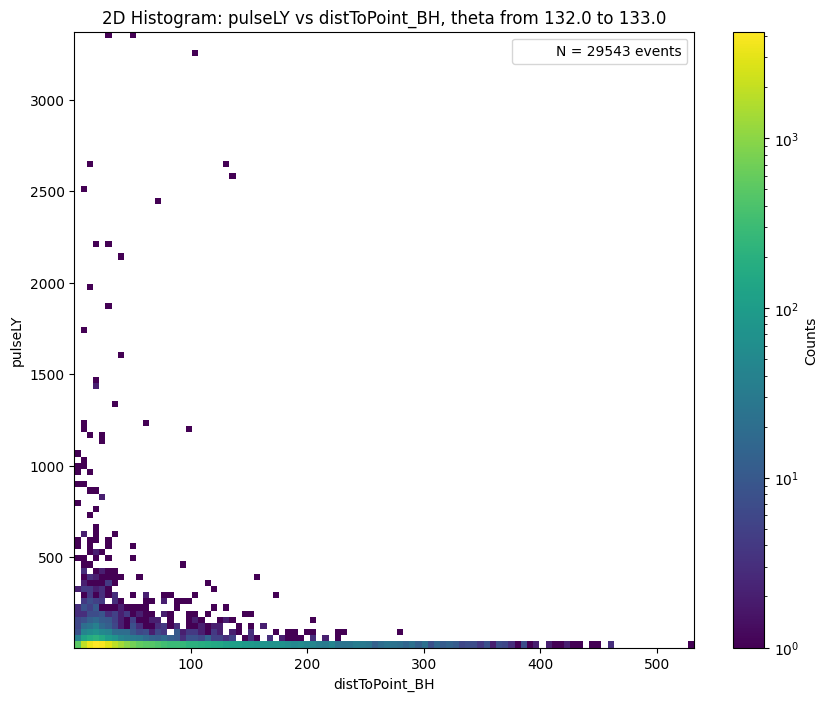

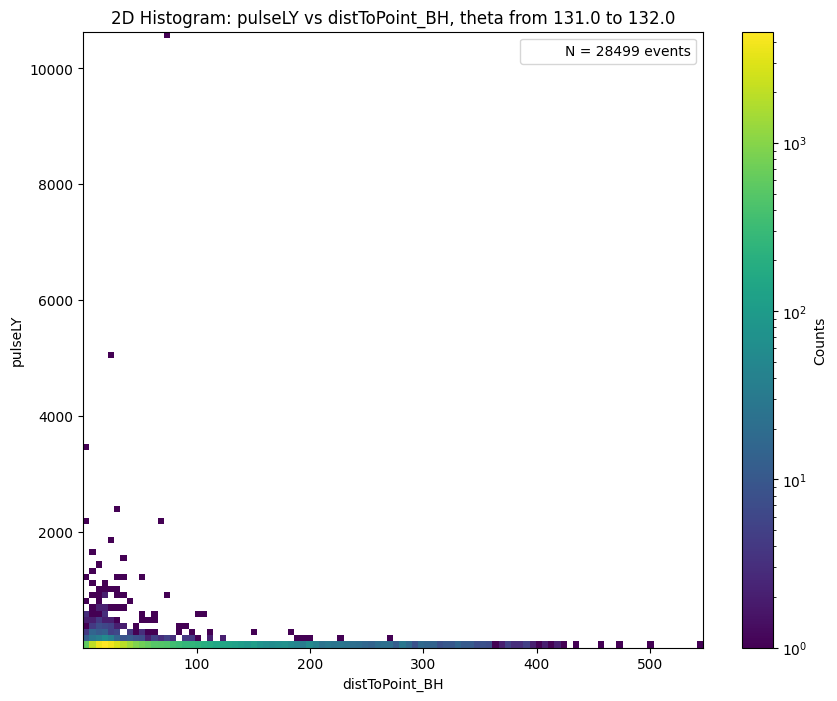

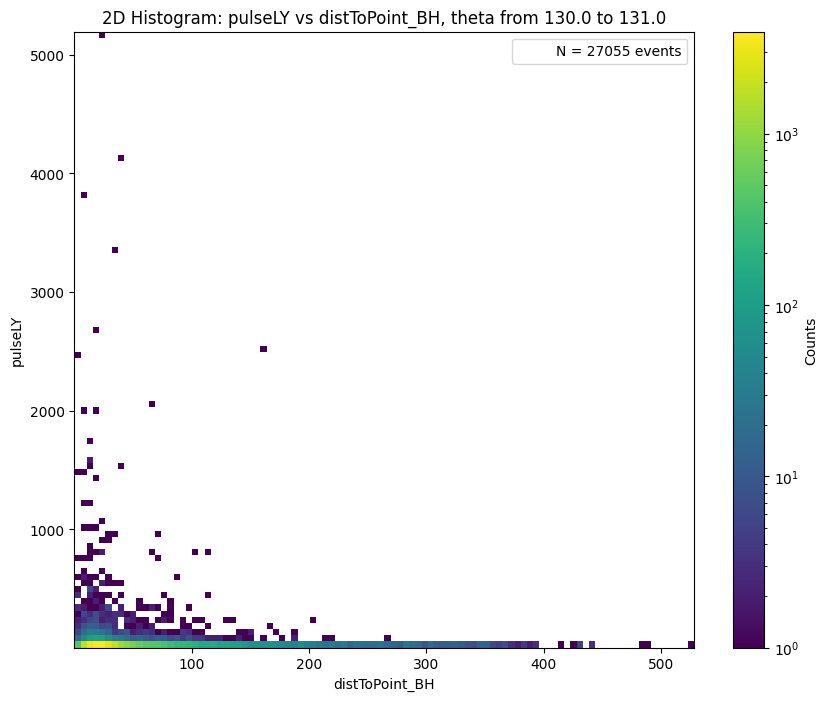

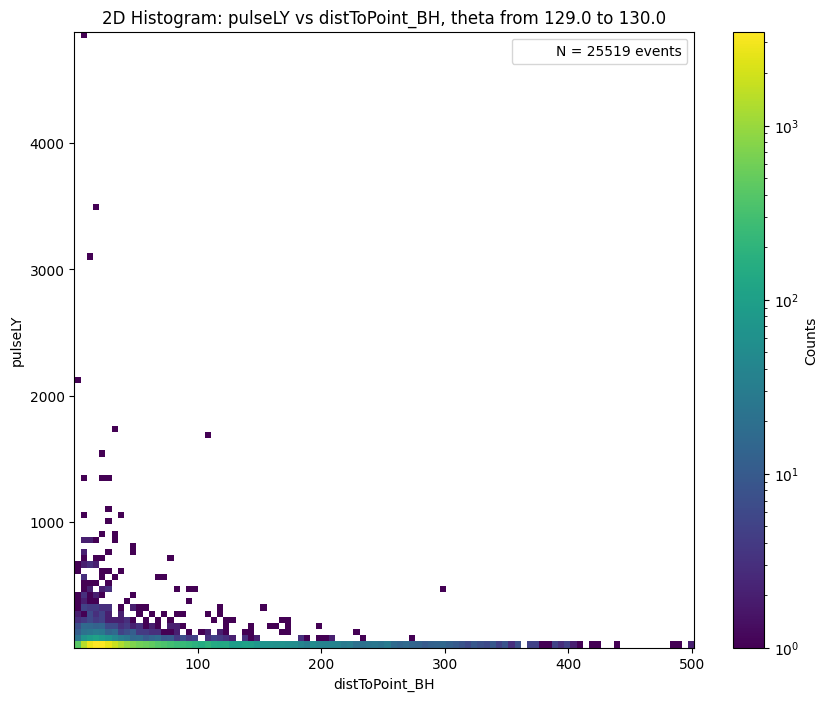

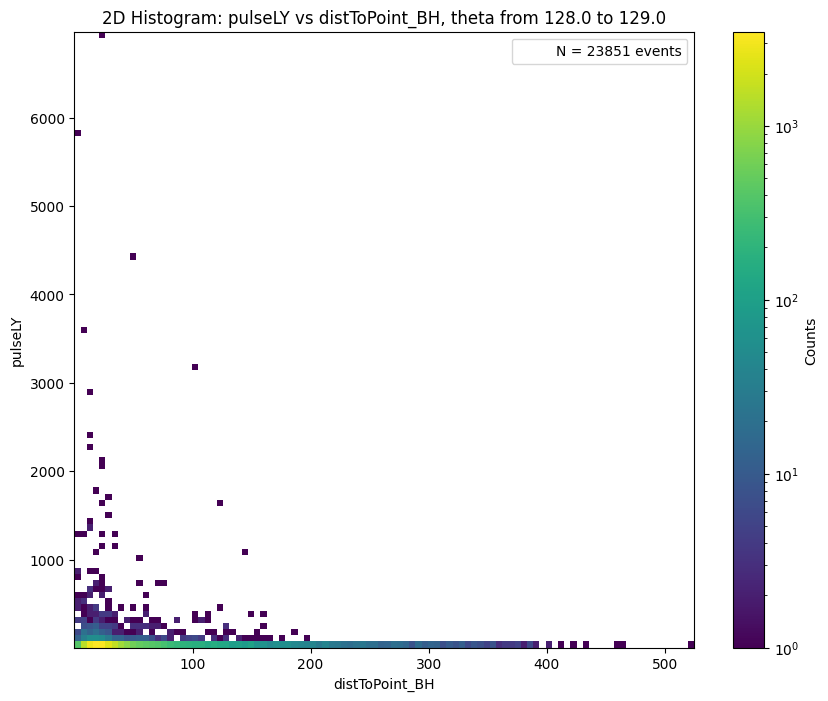

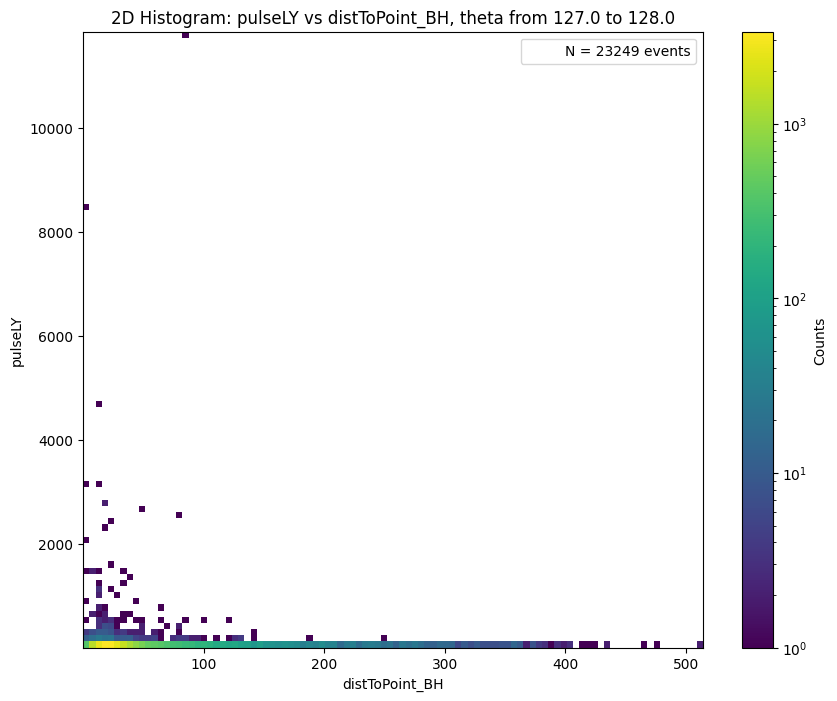

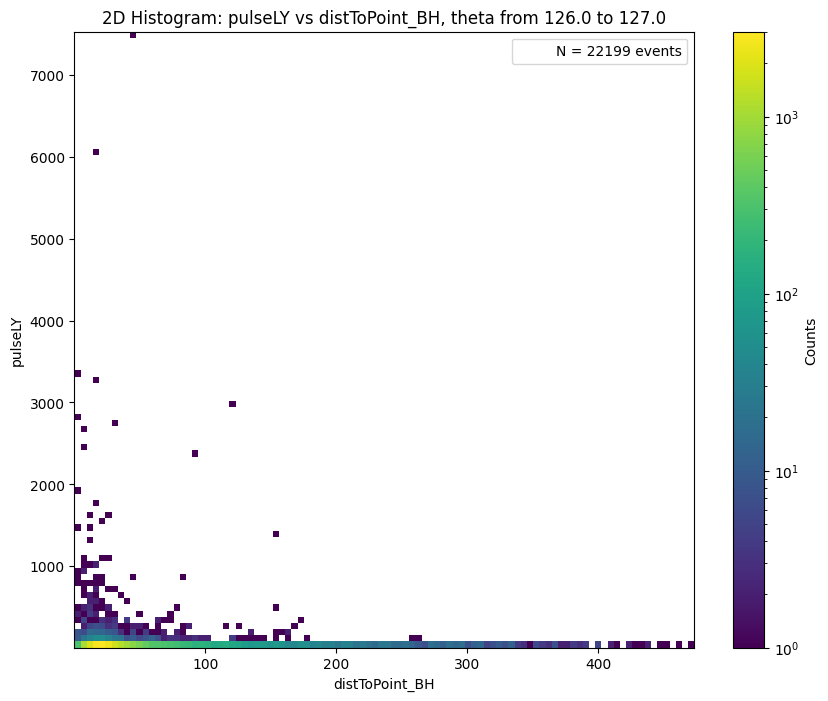

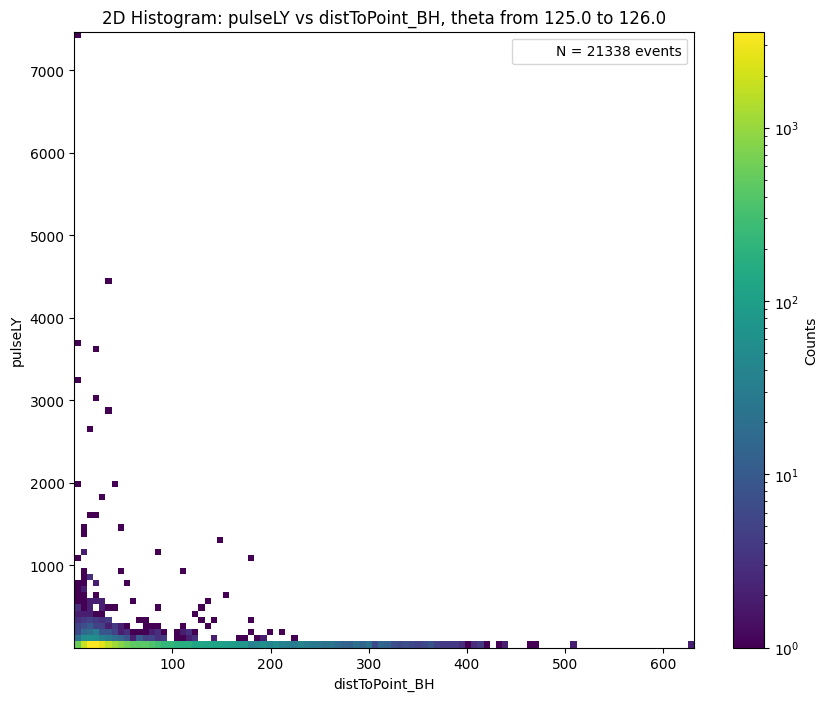

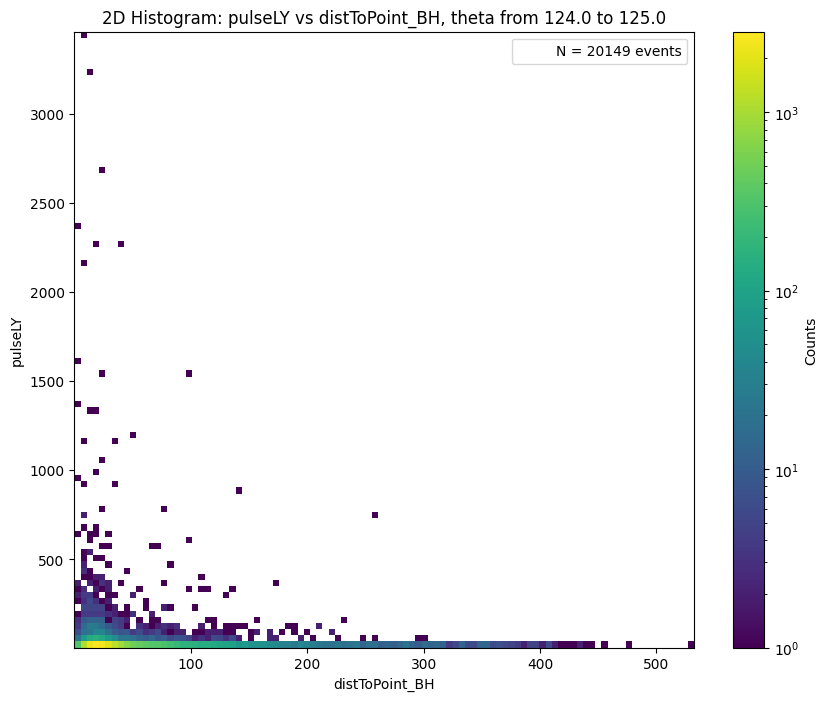

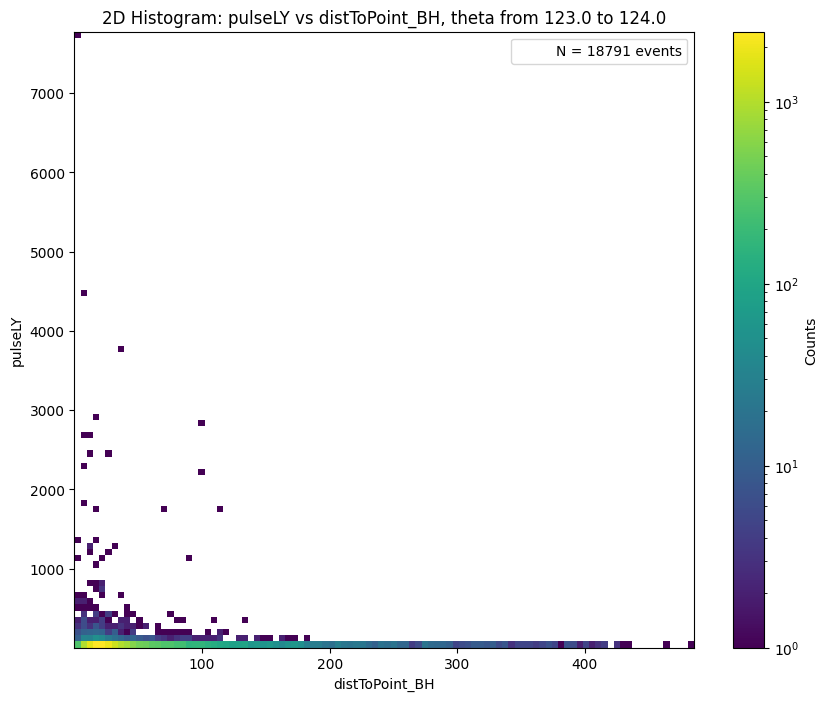

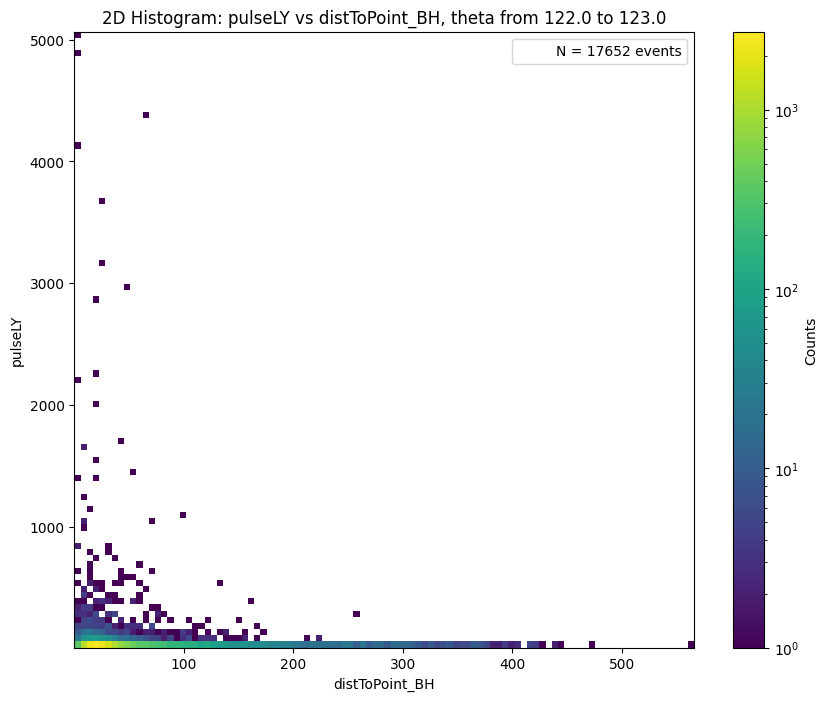

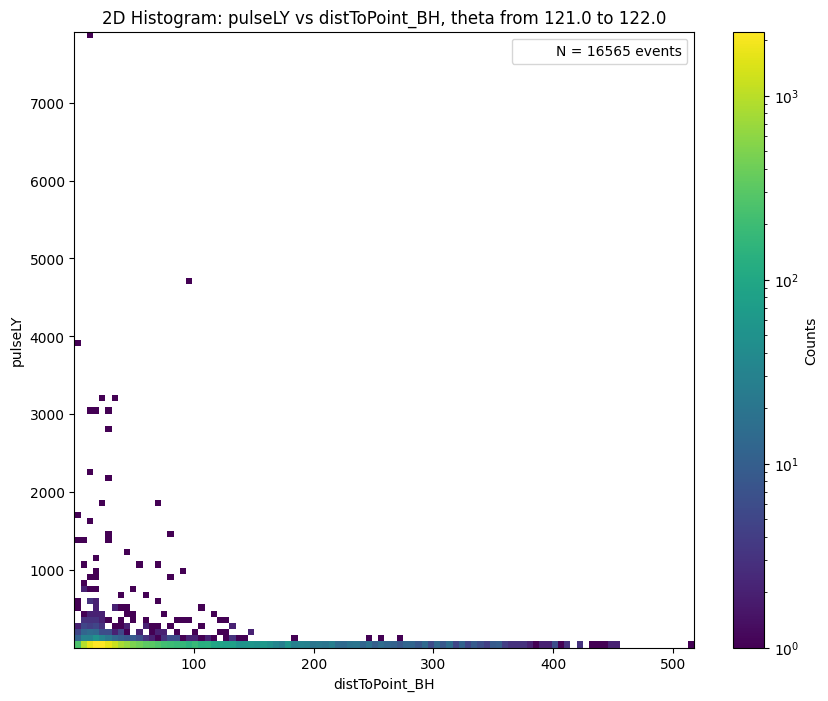

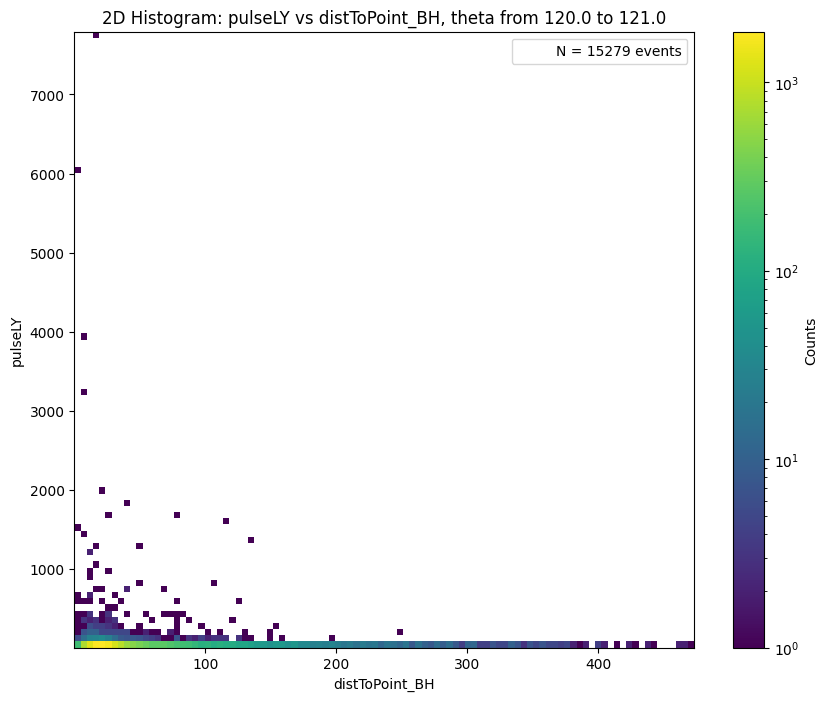

In [74]:
with PdfPages('histograms_theta.pdf') as pdf:
    theta = 180
    step = 1
    
    while theta > 120:
        # Фильтруем данные
        mask = (df_merged.theta > (theta - step)) & (df_merged.theta < theta)
        df_filtered = df_merged.loc[mask]
        
        # Проверяем, что есть данные
        if not df_filtered.empty:
            fig = LY_vs_dist_ploter(df_filtered)
            pdf.savefig(fig)
        else:
            print(f"Нет данных для theta = {theta}")
        
        theta = theta - step

print("PDF сохранен как 'histograms_theta.pdf'")